# Proyecto Predictivo - Analisis y Modelado (Dataset Electrico 2107)

Este notebook contiene el proceso completo de mineria de datos.
No se incluyen tildes por compatibilidad.

In [2]:
# Carpeta de exportacion de figuras para el reporte LaTeX (Overleaf).
# Overleaf-sync (free-tier) no soporta subcarpetas, por lo que las imagenes deben
# quedar en una carpeta plana lista para subir manualmente a la raiz del proyecto.
from pathlib import Path

FIGDIR = Path(r'c:\Universidad\mineria\predictivo\trabajo\figuras')
FIGDIR.mkdir(parents=True, exist_ok=True)
print(f"Carpeta de exportacion de figuras: {FIGDIR}")

Carpeta de exportacion de figuras: c:\Universidad\mineria\predictivo\trabajo\figuras


In [3]:
# Requisitos de reproducibilidad: Python 3.11+, pandas, numpy, matplotlib, seaborn,
# scikit-learn, statsmodels y prophet. Prophet es el unico que no suele venir preinstalado:
#   pip install prophet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuraciones visuales basicas
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
pd.set_option('display.max_columns', 150)

# Carga de datos optimizada
DATA_PATH = Path(r'c:\Universidad\mineria\predictivo\data\2107_electrical_data.csv')

# Determinamos tipos de datos usando una muestra
sample_df = pd.read_csv(DATA_PATH, nrows=10)
dtypes = {col: 'float32' for col in sample_df.columns if col != 'measured_on'}

print("Cargando el dataset...")
df = pd.read_csv(DATA_PATH, dtype=dtypes, parse_dates=['measured_on'])
# Usaremos measured_on como indice temporal
df.set_index('measured_on', inplace=True)
print("Carga completa.")

Cargando el dataset...


Carga completa.


## 1. Comprension Estructural del Dataset

Revisamos inventario de columnas, el rango de fechas y una vista rapida de los datos.

In [4]:
print(f"Dimensiones del dataset: {df.shape}")
print(f"Rango temporal: desde {df.index.min()} hasta {df.index.max()}")
print(f"Total de dias: {(df.index.max() - df.index.min()).days}")

print("\nTipos de variables:")
print(df.dtypes.value_counts())

display(df.head())

Dimensiones del dataset: (632952, 119)
Rango temporal: desde 2017-11-01 00:00:00 hasta 2023-11-07 23:55:00
Total de dias: 2197

Tipos de variables:
float32    119
Name: count, dtype: int64


,inv_01_dc_current_inv_149579,inv_01_dc_voltage_inv_149580,inv_01_ac_current_inv_149581,inv_01_ac_voltage_inv_149582,inv_01_ac_power_inv_149583,inv_02_dc_current_inv_149584,inv_02_dc_voltage_inv_149585,inv_02_ac_current_inv_149586,inv_02_ac_voltage_inv_149587,inv_02_ac_power_inv_149588,inv_03_dc_current_inv_149589,inv_03_dc_voltage_inv_149590,inv_03_ac_current_inv_149591,inv_03_ac_voltage_inv_149592,inv_03_ac_power_inv_149593,inv_04_dc_current_inv_149594,inv_04_dc_voltage_inv_149595,inv_04_ac_current_inv_149596,inv_04_ac_voltage_inv_149597,inv_04_ac_power_inv_149598,inv_05_dc_current_inv_149599,inv_05_ac_current_inv_149601,inv_05_ac_voltage_inv_149602,inv_05_ac_power_inv_149603,inv_06_dc_current_inv_149604,inv_06_dc_voltage_inv_149605,inv_06_ac_current_inv_149606,inv_06_ac_voltage_inv_149607,inv_06_ac_power_inv_149608,inv_07_dc_current_inv_149609,inv_07_dc_voltage_inv_149610,inv_07_ac_current_inv_149611,inv_07_ac_voltage_inv_149612,inv_07_ac_power_inv_149613,inv_08_dc_current_inv_149614,inv_08_dc_voltage_inv_149615,inv_08_ac_current_inv_149616,inv_08_ac_voltage_inv_149617,inv_08_ac_power_inv_149618,inv_09_dc_current_inv_149619,inv_09_dc_voltage_inv_149620,inv_09_ac_current_inv_149621,inv_09_ac_voltage_inv_149622,inv_09_ac_power_inv_149623,inv_10_dc_current_inv_149624,inv_10_dc_voltage_inv_149625,inv_10_ac_current_inv_149626,inv_10_ac_voltage_inv_149627,inv_10_ac_power_inv_149628,inv_11_dc_current_inv_149629,inv_11_dc_voltage_inv_149630,inv_11_ac_current_inv_149631,inv_11_ac_voltage_inv_149632,inv_11_ac_power_inv_149633,inv_12_dc_current_inv_149634,inv_12_dc_voltage_inv_149635,inv_12_ac_current_inv_149636,inv_12_ac_voltage_inv_149637,inv_12_ac_power_inv_149638,inv_13_dc_current_inv_149639,inv_13_dc_voltage_inv_149640,inv_13_ac_current_inv_149641,inv_13_ac_voltage_inv_149642,inv_13_ac_power_inv_149643,inv_14_dc_current_inv_149644,inv_14_dc_voltage_inv_149645,inv_14_ac_current_inv_149646,inv_14_ac_voltage_inv_149647,inv_14_ac_power_inv_149648,inv_15_dc_current_inv_149649,inv_15_dc_voltage_inv_149650,inv_15_ac_current_inv_149651,inv_15_ac_voltage_inv_149652,inv_15_ac_power_iinv_149653,inv_16_dc_current_inv_149654,inv_16_dc_voltage_inv_149655,inv_16_ac_current_inv_149656,inv_16_ac_voltage_inv_149657,inv_16_ac_power_inv_149658,inv_17_dc_current_inv_149659,inv_17_dc_voltage_inv_149660,inv_17_ac_current_inv_149661,inv_17_ac_voltage_inv_149662,inv_17_ac_power_inv_149663,inv_18_dc_current_inv_149664,inv_18_dc_voltage_inv_149665,inv_18_ac_current_inv_149666,inv_18_ac_voltage_inv_149667,inv_18_ac_power_inv_149668,inv_19_dc_current_inv_149669,inv_19_dc_voltage_inv_149670,inv_19_ac_current_inv_149671,inv_19_ac_voltage_inv_149672,inv_19_ac_power_inv_149673,inv_20_dc_current_inv_149674,inv_20_dc_voltage_inv_149675,inv_20_ac_current_inv_149676,inv_20_ac_voltage_inv_149677,inv_20_ac_power_inv_149678,inv_21_dc_current_inv_149679,inv_21_dc_voltage_inv_149680,inv_21_ac_current_inv_149681,inv_21_ac_voltage_inv_149682,inv_21_ac_power_inv_149683,inv_22_dc_current_inv_149684,inv_22_dc_voltage_inv_149685,inv_22_ac_current_inv_149686,inv_22_ac_voltage_inv_149687,inv_22_ac_power_inv_149688,inv_23_dc_current_inv_149689,inv_23_dc_voltage_inv_149690,inv_23_ac_current_inv_149691,inv_23_ac_voltage_inv_149692,inv_23_ac_power_inv_149693,inv_24_dc_current_inv_149694,inv_24_dc_voltage_inv_149695,inv_24_ac_current_inv_149696,inv_24_ac_voltage_inv_149697,inv_24_ac_power_inv_149698
measured_on,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2017-11-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

## 2. Analisis de Calidad del Dato

Siguiendo las mejores practicas, revisamos:
1. Valores nulos
2. Sensores muertos (varianza cero)
3. Sensores con baja variabilidad (std <= 0.1)

In [5]:
# 2.1 Resumen de nulos
nulos = (
    df.isna()
    .sum()
    .rename("conteo_nulos")
    .to_frame()
    .assign(pct_nulos=lambda t: (t["conteo_nulos"] / len(df)) * 100)
    .sort_values("conteo_nulos", ascending=False)
)

columnas_con_nulos = nulos[nulos['conteo_nulos'] > 0]
print(f"Columnas con nulos: {len(columnas_con_nulos)} de {df.shape[1]}")
display(columnas_con_nulos.head(10))

Columnas con nulos: 114 de 119


,conteo_nulos,pct_nulos
inv_04_dc_voltage_inv_149595,1728,0.273006
inv_04_ac_current_inv_149596,1728,0.273006
inv_04_ac_voltage_inv_149597,1728,0.273006
inv_04_ac_power_inv_149598,1728,0.273006
inv_05_dc_current_inv_149599,1728,0.273006
inv_05_ac_current_inv_149601,1728,0.273006
inv_05_ac_voltage_inv_149602,1728,0.273006
inv_04_dc_current_inv_149594,1728,0.273006
inv_08_ac_voltage_inv_149617,1728,0.273006
inv_08_ac_current_inv_149616,1728,0.273006


In [6]:
# 2.2 Varianza cero (sensores muertos)
df_std = df.std(numeric_only=True)
cols_desv_cero = df_std[df_std == 0].index.tolist()

print(f"Sensores con desviacion estandar 0: {len(cols_desv_cero)}")
if len(cols_desv_cero) > 0:
    print(cols_desv_cero)
    # Eliminamos las columnas que no aportan informacion
    df = df.drop(columns=cols_desv_cero)
    print("Columnas eliminadas.")

# 2.3 Baja varianza
tolerancia = 0.1
cols_baja_desv = df.std(numeric_only=True)[df.std(numeric_only=True) <= tolerancia].index.tolist()
print(f"\nSensores con baja variabilidad (<= {tolerancia}): {len(cols_baja_desv)}")
# Por ahora solo listamos las de baja varianza sin eliminarlas hasta tener mas contexto
if len(cols_baja_desv) > 0:
    print(cols_baja_desv[:10]) # Mostramos primeras 10

Sensores con desviacion estandar 0: 0



Sensores con baja variabilidad (<= 0.1): 0


In [7]:
# 2.3 Duplicados (timestamps repetidos y filas identicas)
# En una serie de tiempo el duplicado REAL es un timestamp repetido en el indice.
dup_indice = int(df.index.duplicated().sum())
dup_valores = int(df.duplicated().sum())

print(f"Timestamps duplicados en el indice: {dup_indice}")
print(f"Filas con valores identicos (timestamps distintos): {dup_valores}")
print(f"  -> {dup_valores / len(df):.1%} del dataset")

# Interpretacion: las filas con valores identicos NO son errores de captura.
# Corresponden a las horas de noche, donde los 24 inversores reportan exactamente lo mismo
# (produccion 0). ~48% del dataset = ~12 horas sin sol por dia. Eliminarlas destruiria el
# ciclo diurno de la serie. El unico duplicado que exigiria limpieza (timestamp repetido) es 0.
if dup_indice == 0:
    print("\nConclusion: no hay timestamps duplicados; no se requiere deduplicacion.")
    print("Las filas de valores identicos son las noches (produccion 0) y deben conservarse.")
else:
    print("\nConclusion: existen timestamps duplicados que deben eliminarse antes del modelado.")

Timestamps duplicados en el indice: 0
Filas con valores identicos (timestamps distintos): 305213
  -> 48.2% del dataset

Conclusion: no hay timestamps duplicados; no se requiere deduplicacion.
Las filas de valores identicos son las noches (produccion 0) y deben conservarse.


## 3. Limpieza de Datos (Filtro Fisico)

Antes de realizar la estadistica descriptiva y el EDA visual, debemos filtrar valores fisicamente imposibles originados por fallas en los sensores del SCADA (outliers).
- Voltaje DC: Un inversor de esta categoria no excede los 1500 V.
- Voltaje AC: Conexion a red estandar, no excede 500 V.
- Corriente: No excede 200 A.
- Potencia AC: Maximo nominal ~30 kW (segun descubrimiento previo).

In [8]:
# Filtro fisico de outliers
df_clean = df.copy()

# Listas de columnas por tipo
cols_dc_v = [c for c in df_clean.columns if 'dc_voltage' in c]
cols_ac_v = [c for c in df_clean.columns if 'ac_voltage' in c]
cols_dc_i = [c for c in df_clean.columns if 'dc_current' in c]
cols_ac_i = [c for c in df_clean.columns if 'ac_current' in c]
cols_ac_p = [c for c in df_clean.columns if 'ac_power' in c and 'total' not in c]

# Aplicar mascaras (reemplazar con NaN si superan limites fisicos)
for col in cols_dc_v: df_clean.loc[df_clean[col] > 1500, col] = np.nan
for col in cols_ac_v: df_clean.loc[df_clean[col] > 500, col] = np.nan
for col in cols_dc_i: df_clean.loc[df_clean[col] > 200, col] = np.nan
for col in cols_ac_i: df_clean.loc[df_clean[col] > 200, col] = np.nan
for col in cols_ac_p: df_clean.loc[df_clean[col] > 50, col] = np.nan

# Recalcular total_ac_power con los datos limpios
df_clean['total_ac_power'] = df_clean[cols_ac_p].sum(axis=1)

print("Datos limpios creados exitosamente.")

Datos limpios creados exitosamente.


Apagon SCADA detectado desde: 2023-11-06 17:30:00 hasta 2023-11-07 23:55:00


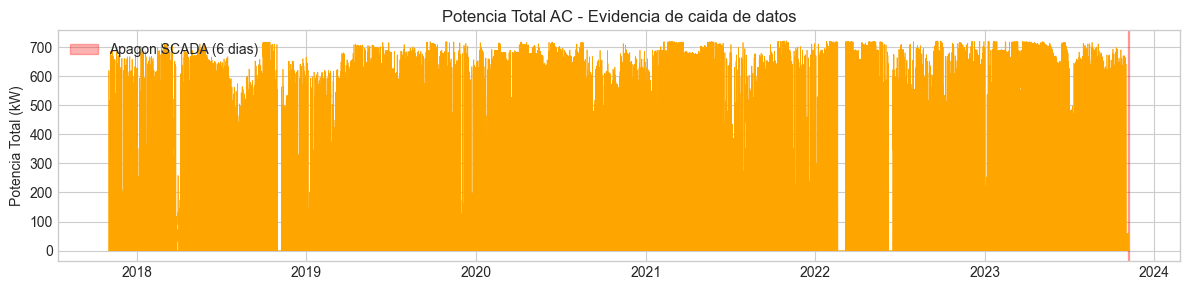

In [9]:
# Localizacion del bloque de 6 dias sin datos
# Usamos una columna especifica para detectar los nulos masivos
col_ref = [c for c in df_clean.columns if 'inv_01_ac_power' in c][0]
filas_nulas = df_clean[col_ref].isna()

if filas_nulas.any():
    fecha_inicio = df_clean[filas_nulas].index.min()
    fecha_fin = df_clean[filas_nulas].index.max()
    print(f"Apagon SCADA detectado desde: {fecha_inicio} hasta {fecha_fin}")
    
    # Graficamos la caida para evidenciarla en el EDA
    plt.figure(figsize=(12, 3))
    plt.plot(df_clean.index, df_clean['total_ac_power'], color='orange', linewidth=0.5)
    plt.axvspan(fecha_inicio, fecha_fin, color='red', alpha=0.3, label='Apagon SCADA (6 dias)')
    plt.title('Potencia Total AC - Evidencia de caida de datos')
    plt.ylabel('Potencia Total (kW)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGDIR / 'fig01_apagon_scada_evidencia.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. Estadisticas Descriptivas Post-Limpieza

Con la basura electronica eliminada, podemos confiar en las medidas de tendencia central y dispersion.

In [10]:
# 4.1 Estadisticas y Coeficiente de Variacion
desc = df_clean.describe().T
desc['cv'] = (desc['std'] / desc['mean']).replace([np.inf, -np.inf], np.nan).round(2)

print("=== Resumen Estadistico de Potencia AC por Inversor ===")
display(desc.loc[cols_ac_p, ['count', 'mean', 'std', 'min', '50%', 'max', 'cv']])

=== Resumen Estadistico de Potencia AC por Inversor ===


,count,mean,std,min,50%,max,cv
inv_01_ac_power_inv_149583,632586.0,6.363338,9.933949,0.0,0.0,30.096001,1.56
inv_02_ac_power_inv_149588,632586.0,5.982282,9.607771,0.0,0.0,30.087999,1.61
inv_03_ac_power_inv_149593,632952.0,6.500056,9.909333,0.0,0.0,30.091999,1.52
inv_04_ac_power_inv_149598,631223.0,6.130188,9.856085,0.0,0.0,30.091999,1.61
inv_05_ac_power_inv_149603,631224.0,6.415813,9.924226,0.0,0.0,30.084999,1.55
inv_06_ac_power_inv_149608,631224.0,5.834427,9.589360,0.0,0.0,30.086000,1.64
inv_07_ac_power_inv_149613,631223.0,5.879632,9.771081,0.0,0.0,30.091999,1.66
inv_08_ac_power_inv_149618,631224.0,6.564618,10.089930,0.0,0.0,30.089001,1.54
inv_09_ac_power_inv_149623,631224.0,6.821695,10.228336,0.0,0.0,30.089001,1.50
inv_10_ac_power_inv_149628,631224.0,6.649021,10.122900,0.0,0.0,30.087999,1.52


## 5. EDA Visual con Contexto Solar

Analizamos graficamente el comportamiento de la planta, aplicando los conceptos del docente pero ajustados a datos solares.

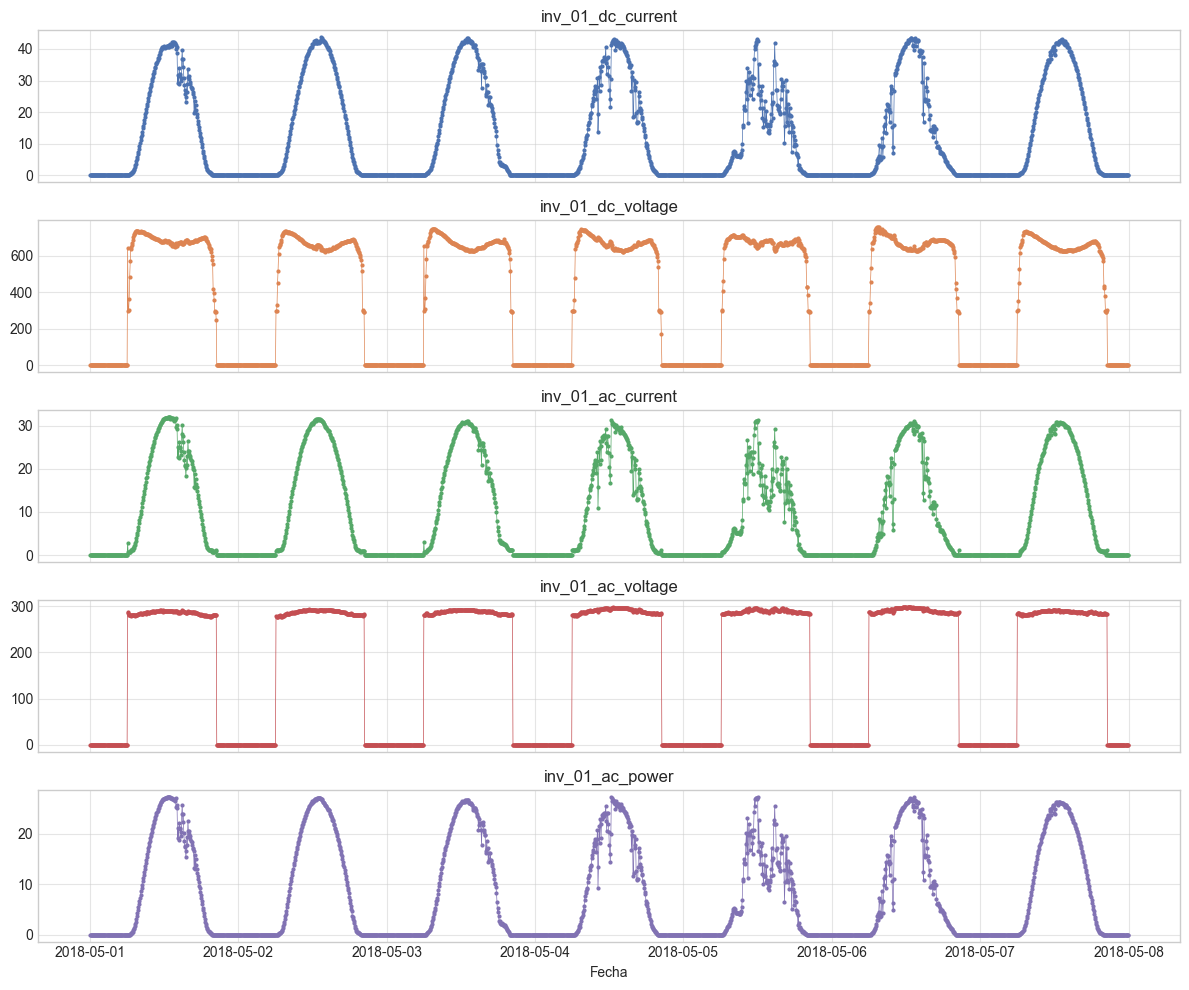

In [11]:
# 5.1 Series de Tiempo Representativas (Inversor 01)
# Extraemos una semana de ejemplo de los datos limpios (Mayo 2018)
df_semana = df_clean.loc['2018-05-01':'2018-05-07']
cols_inv01 = [c for c in df_clean.columns if 'inv_01' in c]

fig, axes = plt.subplots(len(cols_inv01), 1, figsize=(12, 10), sharex=True)
for i, col in enumerate(cols_inv01):
    axes[i].plot(df_semana.index, df_semana[col], marker='o', markersize=2, linestyle='-', linewidth=0.5, color='C'+str(i))
    axes[i].set_title(col.split('_inv')[0])
    axes[i].grid(True, alpha=0.5)

plt.xlabel('Fecha')
plt.tight_layout()
plt.savefig(FIGDIR / 'fig02_series_tiempo_inv01.png', dpi=150, bbox_inches='tight')
plt.show()

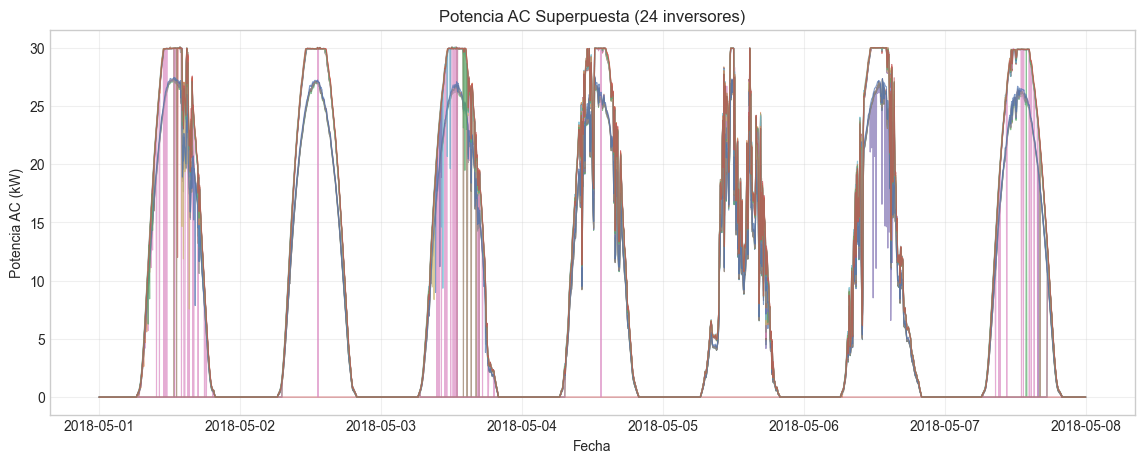

In [12]:
# 5.2 Superposicion de Potencia AC (Homogeneidad de la Planta)
plt.figure(figsize=(14, 5))
for col in cols_ac_p:
    plt.plot(df_semana.index, df_semana[col], linewidth=0.8, alpha=0.7)

plt.title('Potencia AC Superpuesta (24 inversores)')
plt.ylabel('Potencia AC (kW)')
plt.xlabel('Fecha')
plt.grid(True, alpha=0.3)
plt.savefig(FIGDIR / 'fig03_superposicion_potencia_ac.png', dpi=150, bbox_inches='tight')
plt.show()

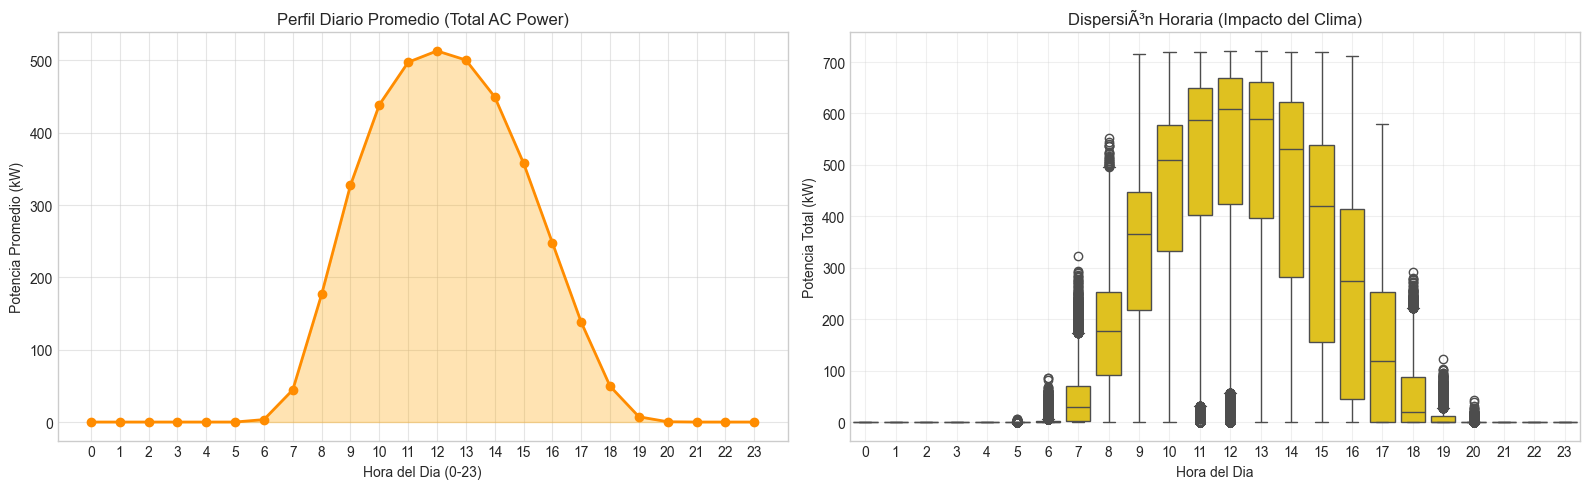

In [13]:
# 5.3 Perfil Diario Promedio y Boxplots de Variabilidad
# Agrupamos por hora del dia
df_hora = df_clean.groupby(df_clean.index.hour)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Promedio horario de potencia total
promedio_hora = df_hora['total_ac_power'].mean()
axes[0].plot(promedio_hora.index, promedio_hora.values, marker='o', color='darkorange', linewidth=2)
axes[0].fill_between(promedio_hora.index, promedio_hora.values, alpha=0.3, color='orange')
axes[0].set_title('Perfil Diario Promedio (Total AC Power)')
axes[0].set_xlabel('Hora del Dia (0-23)')
axes[0].set_ylabel('Potencia Promedio (kW)')
axes[0].set_xticks(range(0, 24))
axes[0].grid(True, alpha=0.5)

# Boxplot horario para ver variabilidad (dias nublados vs soleados)
df_clean['hora'] = df_clean.index.hour
sns.boxplot(x='hora', y='total_ac_power', data=df_clean, ax=axes[1], color='gold')
axes[1].set_title('DispersiÃ³n Horaria (Impacto del Clima)')
axes[1].set_xlabel('Hora del Dia')
axes[1].set_ylabel('Potencia Total (kW)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGDIR / 'fig04_perfil_diario_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
# Borramos la columna auxiliar 'hora' para no afectar futuros calculos
df_clean.drop(columns=['hora'], inplace=True)

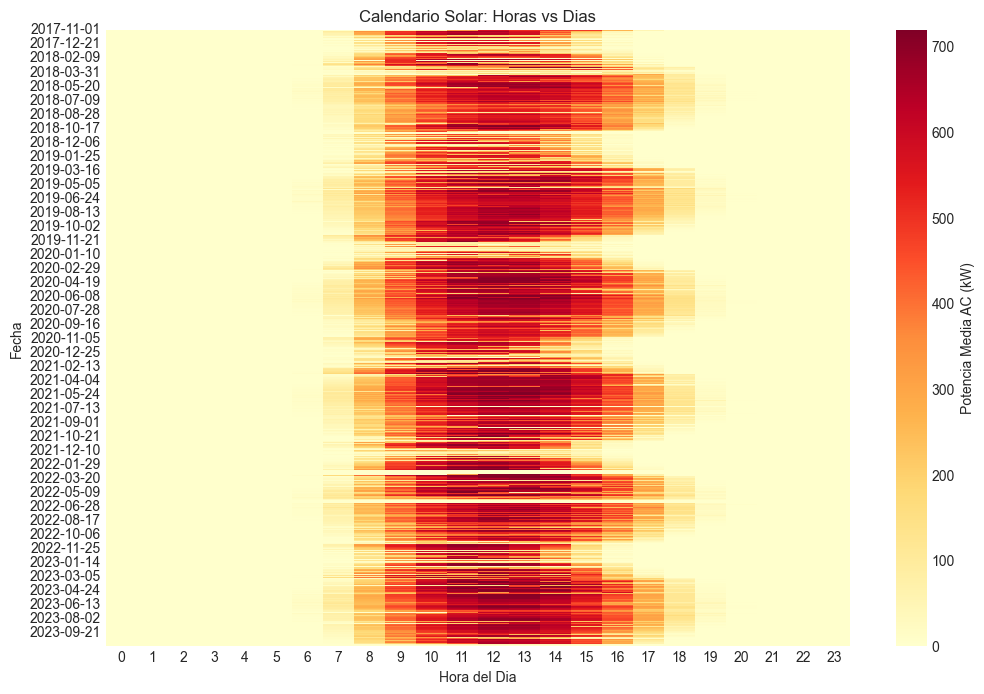

In [14]:
# 5.4 Heatmap de Generacion (Calendario Solar)
# Matriz bidimensional: dia del ano vs hora del dia
df_heatmap = df_clean.copy()
df_heatmap['dia'] = df_heatmap.index.date
df_heatmap['hora'] = df_heatmap.index.hour

# Pivotamos para tener dias en Y y horas en X
matriz_solar = df_heatmap.pivot_table(index='dia', columns='hora', values='total_ac_power', aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(matriz_solar, cmap='YlOrRd', cbar_kws={'label': 'Potencia Media AC (kW)'})
plt.title('Calendario Solar: Horas vs Dias')
plt.xlabel('Hora del Dia')
plt.ylabel('Fecha')
plt.savefig(FIGDIR / 'fig05_heatmap_calendario_solar.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Analisis de Distribuciones y Ceros Nocturnos

Evaluamos como se distribuyen los datos fisicos y cuantificamos el sesgo de la "noche" (produccion 0) en la distribucion total.

Total de registros validos de potencia AC: 15,153,826
Registros exactos en 0 kW (Noche/Apagado): 8,326,606 (54.9%)


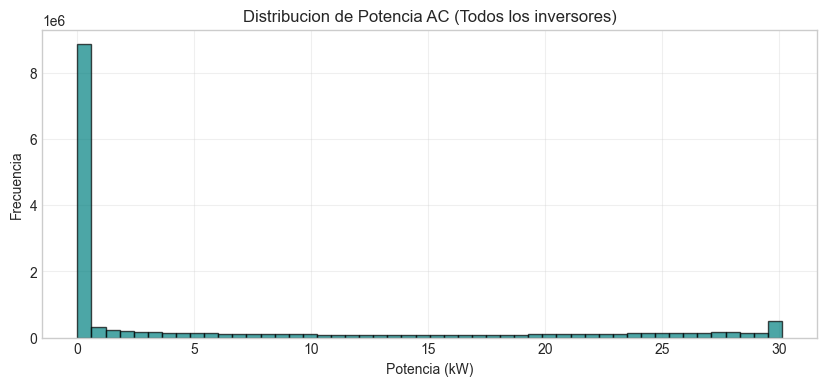

In [15]:
# 6.1 Distribucion Global de ac_power y Cuantificacion de Noches
ac_power_todos = df_clean[cols_ac_p].values.flatten()
ac_power_todos = ac_power_todos[~np.isnan(ac_power_todos)]

ceros = np.sum(ac_power_todos == 0)
total = len(ac_power_todos)
pct_ceros = (ceros / total) * 100

print(f"Total de registros validos de potencia AC: {total:,}")
print(f"Registros exactos en 0 kW (Noche/Apagado): {ceros:,} ({pct_ceros:.1f}%)")

plt.figure(figsize=(10, 4))
plt.hist(ac_power_todos, bins=50, color='teal', edgecolor='black', alpha=0.7)
plt.title('Distribucion de Potencia AC (Todos los inversores)')
plt.xlabel('Potencia (kW)')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)
plt.savefig(FIGDIR / 'fig06_distribucion_ac_power.png', dpi=150, bbox_inches='tight')
plt.show()

# Nota: El pico gigantesco en 0 confirma la extrema bimodalidad del dataset.

## 7. Analisis de Correlacion y Colinealidad (V.I.F)

Como senalo el docente, para la regresion lineal multiple es critico entender la colinealidad.
- Variables fisicas de un mismo inversor (ej. dc_voltage y dc_current) seran nuestras variables predictoras (X).
- ac_power sera nuestra variable objetivo (y).

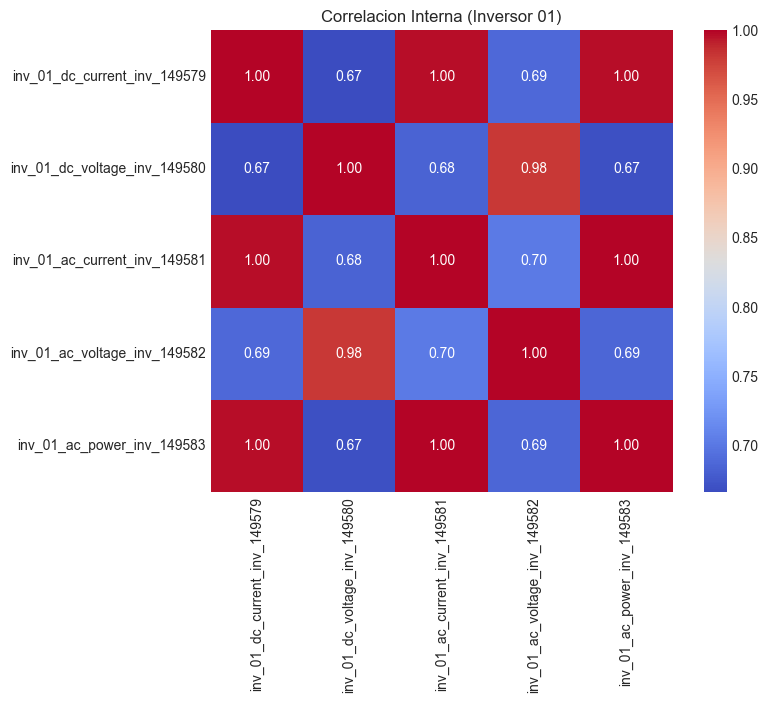

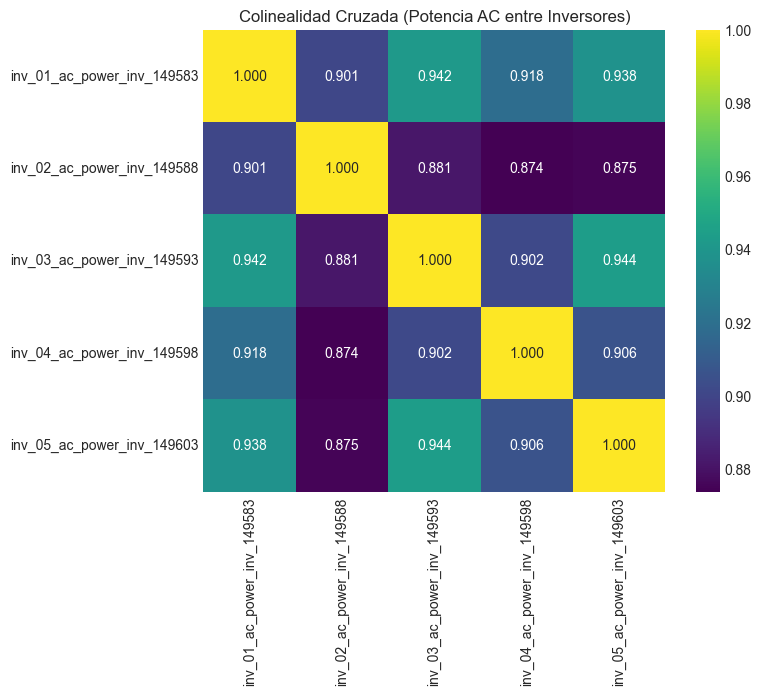

Nota sobre V.I.F:
La correlacion perfecta (~1.0) entre inversores indica alta colinealidad espacial.
Para regresion multiple, usar todos los inversores como predictores causara inestabilidad matematica (inflacion de varianza).


In [16]:
# 7.1 Correlacion Interna (Predictoras vs Objetivo)
# Tomamos el Inversor 01 como muestra representativa
cols_inv01 = [c for c in df_clean.columns if 'inv_01' in c]
df_corr_interna = df_clean[cols_inv01].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr_interna, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlacion Interna (Inversor 01)')
plt.savefig(FIGDIR / 'fig07a_correlacion_inv01.png', dpi=150, bbox_inches='tight')
plt.show()

# 7.2 Colinealidad entre Inversores (AC Power)
cols_ac_muestra = cols_ac_p[:5] # Primeros 5 inversores para no saturar
df_corr_cruzada = df_clean[cols_ac_muestra].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr_cruzada, annot=True, fmt=".3f", cmap='viridis', square=True)
plt.title('Colinealidad Cruzada (Potencia AC entre Inversores)')
plt.savefig(FIGDIR / 'fig07b_colinealidad_cruzada.png', dpi=150, bbox_inches='tight')
plt.show()

print("Nota sobre V.I.F:")
print("La correlacion perfecta (~1.0) entre inversores indica alta colinealidad espacial.")
print("Para regresion multiple, usar todos los inversores como predictores causara inestabilidad matematica (inflacion de varianza).")

## 8. Analisis Temporal Avanzado

Descomponemos la serie temporal para identificar tendencias a largo plazo (degradacion de paneles), estacionalidad y determinamos la estacionariedad con el test de Dickey-Fuller.

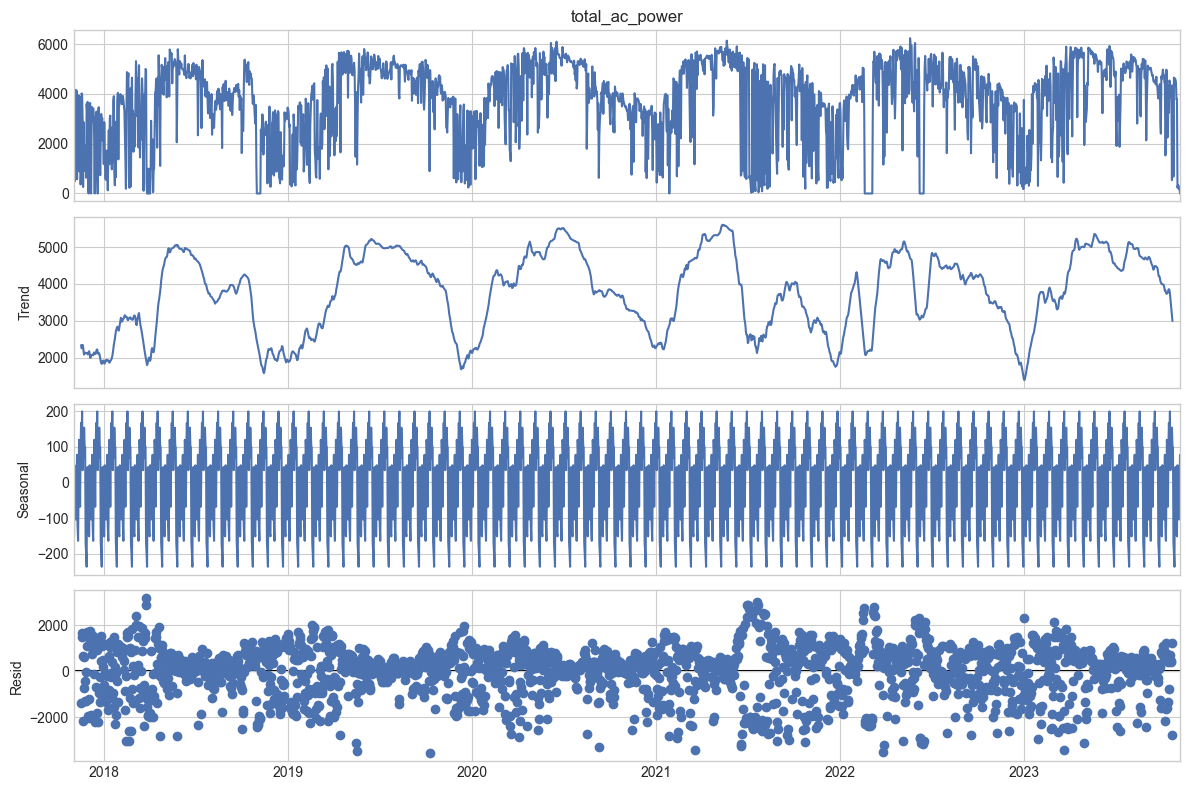

In [17]:
# 8.1 Descomposicion (Tendencia, Estacionalidad, Ruido)
from statsmodels.tsa.seasonal import seasonal_decompose

# Resampleamos a datos diarios (suma de potencia util = Energia aprox)
# Quitamos los nulos para statsmodels y forzamos frecuencia diaria
energia_diaria = df_clean['total_ac_power'].dropna().resample('D').sum() * (5/60)

# Aseguramos que la serie no tenga NaNs intermedios imputandolos
energia_diaria = energia_diaria.fillna(energia_diaria.median())

resultado = seasonal_decompose(energia_diaria, model='additive', period=30) # 30 dias = patron mensual

plt.rcParams.update({'figure.figsize': (12, 8)})
resultado.plot()
plt.tight_layout()
plt.savefig(FIGDIR / 'fig08_descomposicion_estacional.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# 8.2 Test de Estacionariedad (Augmented Dickey-Fuller)
from statsmodels.tsa.stattools import adfuller

result_adf = adfuller(energia_diaria)
print('Estadistico ADF:', result_adf[0])
print('p-value:', result_adf[1])

if result_adf[1] < 0.05:
    print("Conclusion: La serie es ESTACIONARIA (podemos modelar sin diferenciar).")
else:
    print("Conclusion: La serie NO ES ESTACIONARIA (requerira diferenciacion ej. ARIMA d=1).")

Estadistico ADF: -5.077181105286626
p-value: 1.5578275946818143e-05
Conclusion: La serie es ESTACIONARIA (podemos modelar sin diferenciar).


## 9. Preparacion de Datos (Data Preparation)

El objetivo del modelado predictivo sera pronosticar la **Energia Total Diaria** de la planta. Esto es mas util para un operador de red y nos permite reducir la colinealidad extrema colapsando las 119 variables en promedios diarios por planta.

In [19]:
# 9.1 Manejo de Nulos (Apagon SCADA y Filtros Fisicos)
# Eliminamos las filas del apagon SCADA (donde todas las seÃ±ales importantes son nulas simultaneamente)
df_prep = df_clean.dropna(how='all', subset=cols_ac_p)

# Interpolamos linealmente los pequeÃ±os huecos dejados por la limpieza de outliers (inv_04 e inv_07)
# Se hace antes de agregar para no alterar la suma diaria con NaNs
df_prep = df_prep.interpolate(method='time')
# Llenado residual por si quedan nulos en los extremos
df_prep = df_prep.ffill().bfill()

print(f"Filas despues de eliminar apagon SCADA: {len(df_prep)} (original: {len(df_clean)})")

Filas despues de eliminar apagon SCADA: 632952 (original: 632952)


In [20]:
# 9.2 Reduccion de Dimensionalidad a Nivel de Planta y Agregacion Diaria
# Calculamos variables agregadas a nivel de planta por cada intervalo de 5 minutos
df_prep['planta_ac_power'] = df_prep[cols_ac_p].sum(axis=1) # Usamos la potencia total
df_prep['planta_dc_voltage'] = df_prep[cols_dc_v].mean(axis=1)
df_prep['planta_dc_current'] = df_prep[cols_dc_i].mean(axis=1)
df_prep['planta_ac_voltage'] = df_prep[cols_ac_v].mean(axis=1)
df_prep['planta_ac_current'] = df_prep[cols_ac_i].mean(axis=1)

# Nos quedamos solo con las variables resumen de planta
cols_planta = ['planta_ac_power', 'planta_dc_voltage', 'planta_dc_current', 'planta_ac_voltage', 'planta_ac_current']
df_planta = df_prep[cols_planta]

# AGREGACION DIARIA
# Para predecir la energia total del dia, resampleamos los datos a frecuencia diaria ('D')
# La potencia (kW) se suma y se divide entre 12 (5 min x 12 = 1 hr) para obtener Energia (kWh)
# Los voltajes y corrientes se promedian
agregaciones = {
    'planta_ac_power': lambda x: x.sum() / 12, # Convertir sumatoria de potencia 5-min a Energia en kWh
    'planta_dc_voltage': 'mean',
    'planta_dc_current': 'mean',
    'planta_ac_voltage': 'mean',
    'planta_ac_current': 'mean'
}
df_diario = df_planta.resample('D').agg(agregaciones)
df_diario.rename(columns={'planta_ac_power': 'energia_diaria_kwh'}, inplace=True)

# Filtramos dias sin ninguna generacion (el hueco del apagon puede generar un dia vacio)
df_diario = df_diario[df_diario['energia_diaria_kwh'] > 0]

print(f"Dataset convertido a resolucion diaria. Total de dias validos: {len(df_diario)}")
display(df_diario.head())

Dataset convertido a resolucion diaria. Total de dias validos: 2153


,energia_diaria_kwh,planta_dc_voltage,planta_dc_current,planta_ac_voltage,planta_ac_current
measured_on,,,,,
2017-11-01,3955.671631,309.006683,10.303677,131.428192,8.013981
2017-11-02,2074.802979,225.937180,5.312757,90.215042,4.269296
2017-11-03,479.167480,289.097260,1.268173,123.802940,0.963462
2017-11-04,2819.031250,292.809662,7.218731,124.830566,5.701476
2017-11-05,4159.281738,310.600159,10.514863,132.737701,8.177784


In [21]:
# 9.3 Feature Engineering Temporal
# Extraemos caracteristicas del indice de tiempo (fecha)
df_diario['mes'] = df_diario.index.month
df_diario['dia_semana'] = df_diario.index.dayofweek

# Transformacion ciclica para el mes (evita que Dic(12) y Ene(1) se vean como opuestos)
df_diario['mes_sin'] = np.sin(2 * np.pi * df_diario['mes'] / 12)
df_diario['mes_cos'] = np.cos(2 * np.pi * df_diario['mes'] / 12)

# Eliminamos la columna original 'mes' para evitar redundancia
df_diario.drop(columns=['mes'], inplace=True)

print("Nuevas caracteristicas temporales creadas (mes_sin, mes_cos, dia_semana).")
display(df_diario.head(2))

Nuevas caracteristicas temporales creadas (mes_sin, mes_cos, dia_semana).


,energia_diaria_kwh,planta_dc_voltage,planta_dc_current,planta_ac_voltage,planta_ac_current,dia_semana,mes_sin,mes_cos
measured_on,,,,,,,,
2017-11-01,3955.671631,309.006683,10.303677,131.428192,8.013981,2,-0.5,0.866025
2017-11-02,2074.802979,225.937180,5.312757,90.215042,4.269296,3,-0.5,0.866025


Dimension de Train: (1722, 7)
Dimension de Test: (431, 7)


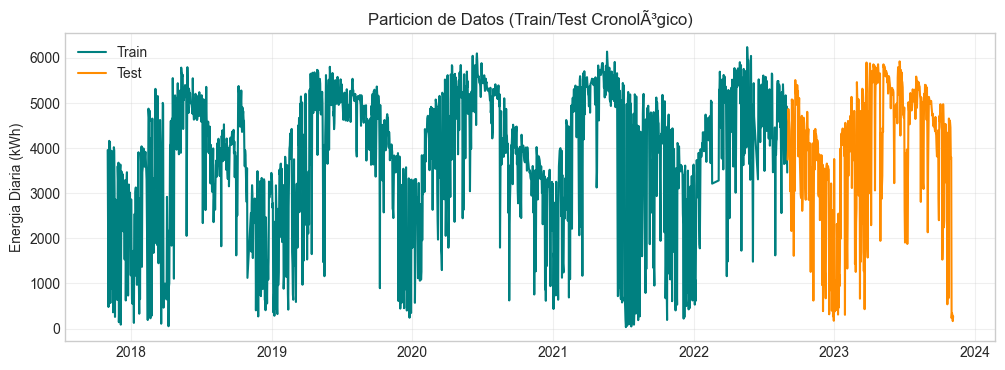

In [22]:
# 9.4 Particion Cronologica (Train/Test) y Escalado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Definimos variables predictoras (X) y objetivo (y)
# NOTA: Para predecir la energia de hoy, idealmente usariamos datos de 'ayer', pero
# en un modelo base, usamos las proyecciones o promedios esperados de voltaje/corriente.
X = df_diario.drop(columns=['energia_diaria_kwh'])
y = df_diario['energia_diaria_kwh']

# Particion temporal 80% Train, 20% Test (NO aleatorio, shuffle=False)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Escalado
scaler_X = StandardScaler()
# Solo entrenamos el scaler con los datos de TRAIN para evitar data leakage
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Convertimos de vuelta a DataFrame para no perder los nombres de las columnas ni el indice
X_train_scaled = pd.DataFrame(X_train_scaled, index=X_train.index, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, index=X_test.index, columns=X.columns)

print(f"Dimension de Train: {X_train.shape}")
print(f"Dimension de Test: {X_test.shape}")

# Visualizacion de la particion
plt.figure(figsize=(12, 4))
plt.plot(y_train.index, y_train, label='Train', color='teal')
plt.plot(y_test.index, y_test, label='Test', color='darkorange')
plt.title('Particion de Datos (Train/Test CronolÃ³gico)')
plt.ylabel('Energia Diaria (kWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIGDIR / 'fig09_particion_train_test_supervisado.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Aprendizaje Supervisado: Prediccion de Energia Diaria

Con la particion cronologica y el escalado listos (seccion 9.4), entrenamos dos modelos competidores
para predecir la **energia total diaria de la planta (kWh)**:

1. **Regresion Lineal Multiple (RLM):** modelo base interpretable. Como la fisica del sistema es
   lineal (Potencia = Voltaje x Corriente), esperamos que capture bien la relacion.
2. **Random Forest Regressor:** modelo no lineal de ensamble. No requiere escalado, es robusto a
   outliers y nos entrega la importancia de cada variable.

**Variables predictoras (X):** promedios diarios de planta (voltaje/corriente DC y AC) + features
temporales ciclicos (mes_sin, mes_cos, dia_semana).
**Variable objetivo (y):** `energia_diaria_kwh`.

**Baseline de referencia:** predecir siempre la media del train. Cualquier modelo util debe superar
ampliamente este piso.

=== Coeficientes de la RLM (variables escaladas) ===
planta_ac_current    1472.79
planta_dc_voltage     -80.40
planta_ac_voltage      68.17
mes_cos                64.02
planta_dc_current      62.84
mes_sin                36.25
dia_semana             13.37

Intercepto: 3795.65 kWh (energia diaria promedio del train)


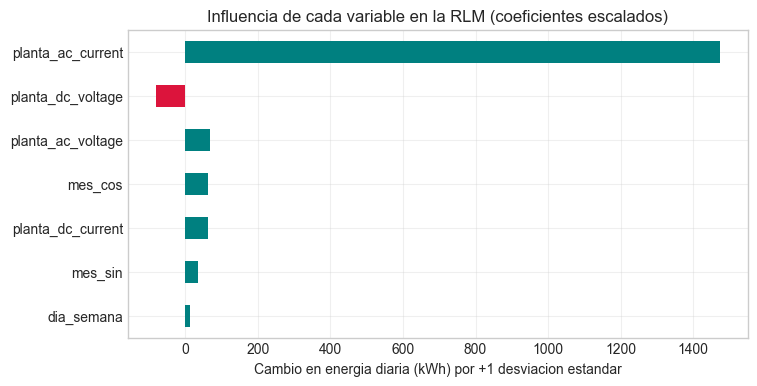

In [23]:
# 10.1 Modelo 1: Regresion Lineal Multiple (baseline interpretable)
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
pred_lr = lin_reg.predict(X_test_scaled)

# Coeficientes sobre datos escalados: comparables entre si (magnitud = influencia)
coefs = pd.Series(lin_reg.coef_, index=X_train_scaled.columns).sort_values(key=abs, ascending=False)

print("=== Coeficientes de la RLM (variables escaladas) ===")
print(coefs.round(2).to_string())
print(f"\nIntercepto: {lin_reg.intercept_:.2f} kWh (energia diaria promedio del train)")

plt.figure(figsize=(8, 4))
coefs.plot(kind='barh', color=['crimson' if v < 0 else 'teal' for v in coefs])
plt.title('Influencia de cada variable en la RLM (coeficientes escalados)')
plt.xlabel('Cambio en energia diaria (kWh) por +1 desviacion estandar')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.savefig(FIGDIR / 'fig10_coeficientes_rlm.png', dpi=150, bbox_inches='tight')
plt.show()

Mejores hiperparametros (CV temporal, 3 folds): {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 100}
RMSE promedio de validacion: 83.2 kWh

=== Importancia de variables (Random Forest ajustado) ===
planta_ac_current    0.9489
planta_dc_current    0.0493
mes_sin              0.0005
mes_cos              0.0005
planta_ac_voltage    0.0004
planta_dc_voltage    0.0003
dia_semana           0.0002


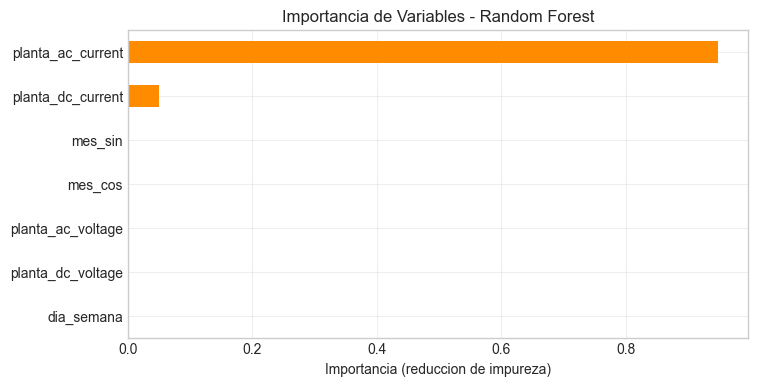

In [24]:
# 10.2 Modelo 2: Random Forest Regressor (competidor no lineal) con ajuste de hiperparametros
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Ajuste de hiperparametros con validacion cruzada TEMPORAL (TimeSeriesSplit):
# cada fold valida sobre dias posteriores a los de entrenamiento, respetando la cronologia
# (un KFold aleatorio inflaria las metricas por fuga de informacion temporal).
param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 5],
}
tscv = TimeSeriesSplit(n_splits=3)
grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid, cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1,
)
# RF no necesita escalado: usamos X_train/X_test originales para importancias interpretables
grid_rf.fit(X_train, y_train)

print(f"Mejores hiperparametros (CV temporal, 3 folds): {grid_rf.best_params_}")
print(f"RMSE promedio de validacion: {-grid_rf.best_score_:.1f} kWh")

rf_reg = grid_rf.best_estimator_
pred_rf = rf_reg.predict(X_test)

importancias = pd.Series(rf_reg.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print("\n=== Importancia de variables (Random Forest ajustado) ===")
print(importancias.round(4).to_string())

plt.figure(figsize=(8, 4))
importancias.plot(kind='barh', color='darkorange')
plt.title('Importancia de Variables - Random Forest')
plt.xlabel('Importancia (reduccion de impureza)')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.savefig(FIGDIR / 'fig11_importancia_rf.png', dpi=150, bbox_inches='tight')
plt.show()

=== Resultados en el conjunto de Test (431 dias) ===


,RMSE (kWh),MAE (kWh),R2
Modelo,,,
Baseline (media del train),1481.3901,1230.8579,-0.0134
Regresion Lineal Multiple,73.7429,57.4426,0.9975
Random Forest,71.9466,55.5907,0.9976


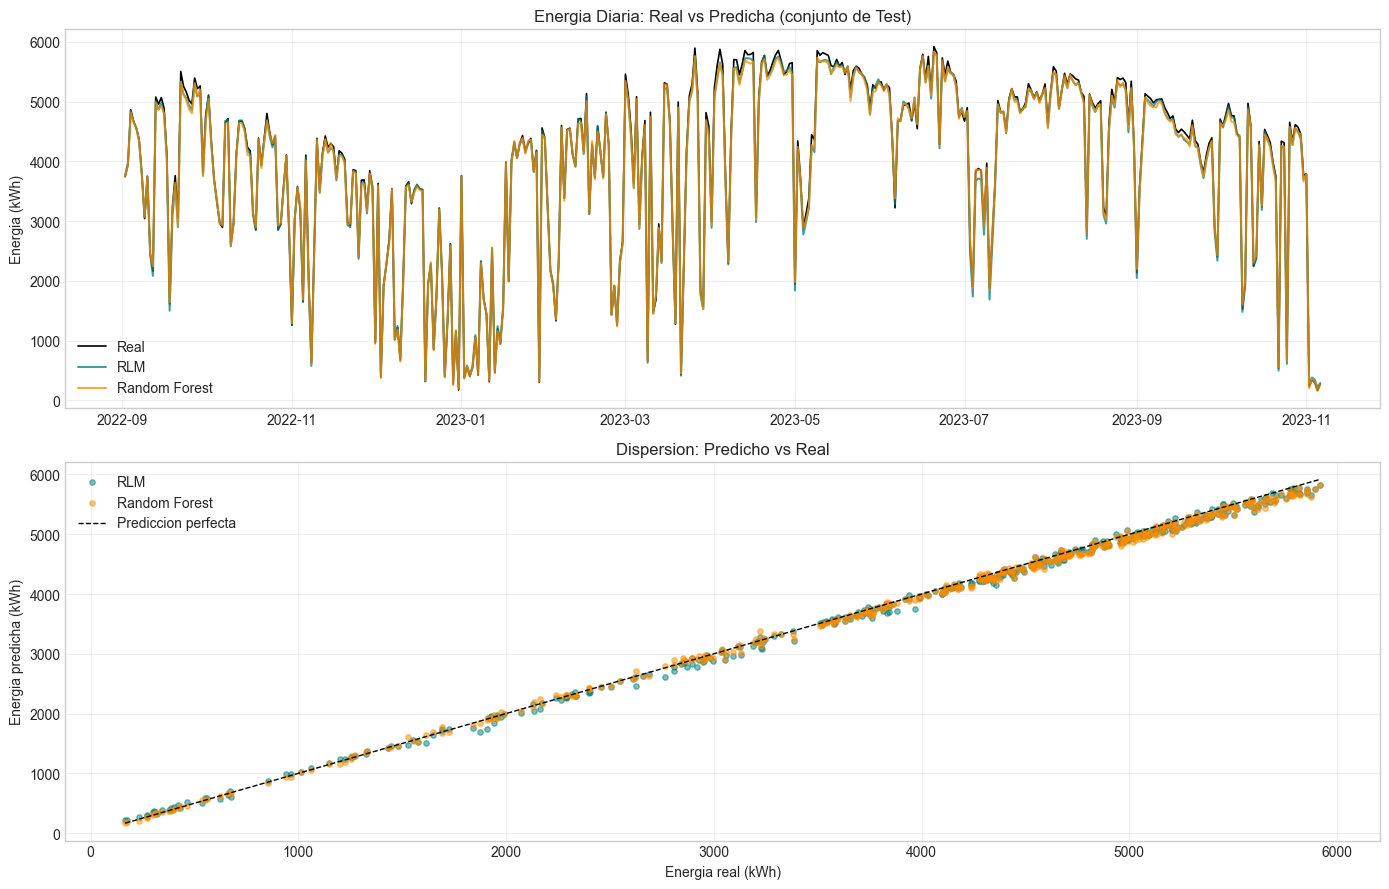

In [25]:
# 10.3 Evaluacion Comparativa en Test (RMSE, MAE, R2)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluar(nombre, y_true, y_pred):
    return {
        'Modelo': nombre,
        'RMSE (kWh)': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE (kWh)': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
    }

# Baseline ingenuo: predecir siempre la media del train
pred_baseline = np.full(len(y_test), y_train.mean())

resultados = pd.DataFrame([
    evaluar('Baseline (media del train)', y_test, pred_baseline),
    evaluar('Regresion Lineal Multiple', y_test, pred_lr),
    evaluar('Random Forest', y_test, pred_rf),
]).set_index('Modelo').round(4)

print("=== Resultados en el conjunto de Test (431 dias) ===")
display(resultados)

# Grafico 1: Prediccion vs Real en el tiempo (test cronologico)
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
axes[0].plot(y_test.index, y_test, label='Real', color='black', linewidth=1.2)
axes[0].plot(y_test.index, pred_lr, label='RLM', color='teal', alpha=0.75)
axes[0].plot(y_test.index, pred_rf, label='Random Forest', color='darkorange', alpha=0.75)
axes[0].set_title('Energia Diaria: Real vs Predicha (conjunto de Test)')
axes[0].set_ylabel('Energia (kWh)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Grafico 2: Dispersion Predicho vs Real con diagonal perfecta
axes[1].scatter(y_test, pred_lr, alpha=0.5, s=15, color='teal', label='RLM')
axes[1].scatter(y_test, pred_rf, alpha=0.5, s=15, color='darkorange', label='Random Forest')
lims = [min(y_test.min(), pred_lr.min()), max(y_test.max(), pred_lr.max())]
axes[1].plot(lims, lims, 'k--', linewidth=1, label='Prediccion perfecta')
axes[1].set_title('Dispersion: Predicho vs Real')
axes[1].set_xlabel('Energia real (kWh)')
axes[1].set_ylabel('Energia predicha (kWh)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGDIR / 'fig12_prediccion_vs_real_supervisado.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusion Parcial del Aprendizaje Supervisado

| Modelo | RMSE (kWh) | MAE (kWh) | R2 |
|---|---|---|---|
| Baseline (media del train) | ~1481 | ~1231 | ~ -0.01 |
| Regresion Lineal Multiple | ~74 | ~57 | ~0.998 |
| Random Forest (ajustado) | ~72 | ~56 | ~0.998 |

**Lectura de resultados:**
- Ambos modelos reducen el error del baseline en un **95%** (de ~1481 a ~72 kWh de RMSE, sobre una
  media diaria de ~3966 kWh: error relativo menor al 2%).
- El Random Forest se ajusto con **GridSearchCV sobre validacion cruzada temporal (TimeSeriesSplit,
  3 folds)**: el mejor set fue `max_depth=20, min_samples_leaf=1, n_estimators=100`, con RMSE de
  validacion de ~83 kWh, consistente con el test (~72 kWh, sin sobreajuste).
- **Random Forest gana por un margen minimo, pero es un empate tecnico.** La razon: la relacion
  fisica subyacente es casi perfectamente lineal (Energia ~ Corriente x Voltaje), por lo que la RLM
  no deja casi nada sobre la mesa. Ni siquiera el tuning de hiperparametros cambia esta conclusion.
- Tanto los coeficientes de la RLM como las importancias del RF (~94.9%) coinciden: la
  **corriente AC promedio del dia (`planta_ac_current`)** es la variable dominante. Esto es
  fisicamente coherente: con voltaje de red casi constante (~280 V), la potencia inyectada es
  proporcional a la corriente.
- **Limitacion honesta:** las predictoras son mediciones del mismo dia que se quiere predecir
  (nowcasting/diagnostico). Este modelo sirve para validar la coherencia de la planta y detectar
  dias anomalos (real muy distinto a lo esperado), no para pronosticar el futuro. El pronostico
  real se aborda en la seccion de Forecasting con la serie temporal.

## 11. Aprendizaje No Supervisado: Deteccion de Anomalias (Mantenimiento Predictivo)

Vamos a enfrentar a **Isolation Forest** vs **DBSCAN** para encontrar fallas sutiles en el equipo fisico.
Utilizaremos los datos de alta resolucion (5 minutos) del **Inversor 01**, filtrando las noches para que los algoritmos se concentren exclusivamente en el rendimiento de conversion solar.

In [26]:
# 10.1 Preparacion de Datos Granulares (Inversor 01)
# Tomamos el dataset preparado de 5 minutos (antes de la agregacion diaria)
# Seleccionamos las variables clave del Inversor 01 (busqueda dinamica por nombre)
col_v_dc = [c for c in df_prep.columns if 'inv_01' in c and 'dc_voltage' in c][0]
col_i_dc = [c for c in df_prep.columns if 'inv_01' in c and 'dc_current' in c][0]
col_p_ac = [c for c in df_prep.columns if 'inv_01' in c and 'ac_power' in c][0]

cols_anomalia = [col_v_dc, col_i_dc, col_p_ac]

# Para evitar MemoryError en DBSCAN (O(N^2)), usamos los datos de un solo ano (2018)
df_anom = df_prep.loc['2018-01-01':'2018-12-31', cols_anomalia].copy()

# Renombramos para facilitar el codigo y graficos
df_anom.columns = ['dc_voltage', 'dc_current', 'ac_power']
cols_anomalia = ['dc_voltage', 'dc_current', 'ac_power'] # Actualizamos la lista para los modelos

# Filtramos las horas de noche. Si la potencia es 0 o casi 0, es de noche o esta apagado.
df_anom = df_anom[df_anom['ac_power'] > 0.1]
df_anom.dropna(inplace=True)

print(f"Datos diurnos del Inversor 01 (AÃ±o 2018) listos para inspeccion: {len(df_anom)} registros.")
display(df_anom.head(2))

Datos diurnos del Inversor 01 (AÃ±o 2018) listos para inspeccion: 40624 registros.


,dc_voltage,dc_current,ac_power
measured_on,,,
2018-01-01 07:45:00,535.593018,0.528,0.189
2018-01-01 07:50:00,532.068970,0.755,0.271


In [27]:
# 10.2 Modelo 1: Isolation Forest
from sklearn.ensemble import IsolationForest

# Configuramos con 1% de contaminacion (asumimos que 1 de cada 100 registros podria ser una falla)
iso_forest = IsolationForest(contamination=0.01, random_state=42)

# Entrenamos y predecimos
# Devuelve 1 para inliers (normal) y -1 para outliers (anomalias)
df_anom['anomalia_iso'] = iso_forest.fit_predict(df_anom[cols_anomalia])

anomalias_iso_count = (df_anom['anomalia_iso'] == -1).sum()
print(f"Isolation Forest detecto {anomalias_iso_count} anomalias.")

Isolation Forest detecto 407 anomalias.


In [28]:
# 10.3 Modelo 2: DBSCAN
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# DBSCAN es extremadamente sensible a las escalas, por lo que ESCALAR ES OBLIGATORIO
scaler_dbscan = StandardScaler()
X_anom_scaled = scaler_dbscan.fit_transform(df_anom[cols_anomalia])

# eps = distancia maxima para considerar que dos puntos son vecinos
# min_samples = minimo de puntos para formar un grupo denso (cluster normal)
dbscan = DBSCAN(eps=0.5, min_samples=10)

# Devuelve etiquetas de cluster (0, 1, 2...) y -1 para las anomalias (ruido)
df_anom['anomalia_dbscan'] = dbscan.fit_predict(X_anom_scaled)

# Convertimos los inliers a 1 y outliers a -1 para coincidir con el formato de Isolation Forest
df_anom['anomalia_dbscan'] = df_anom['anomalia_dbscan'].apply(lambda x: -1 if x == -1 else 1)

anomalias_dbs_count = (df_anom['anomalia_dbscan'] == -1).sum()
print(f"DBSCAN detecto {anomalias_dbs_count} anomalias.")

DBSCAN detecto 102 anomalias.


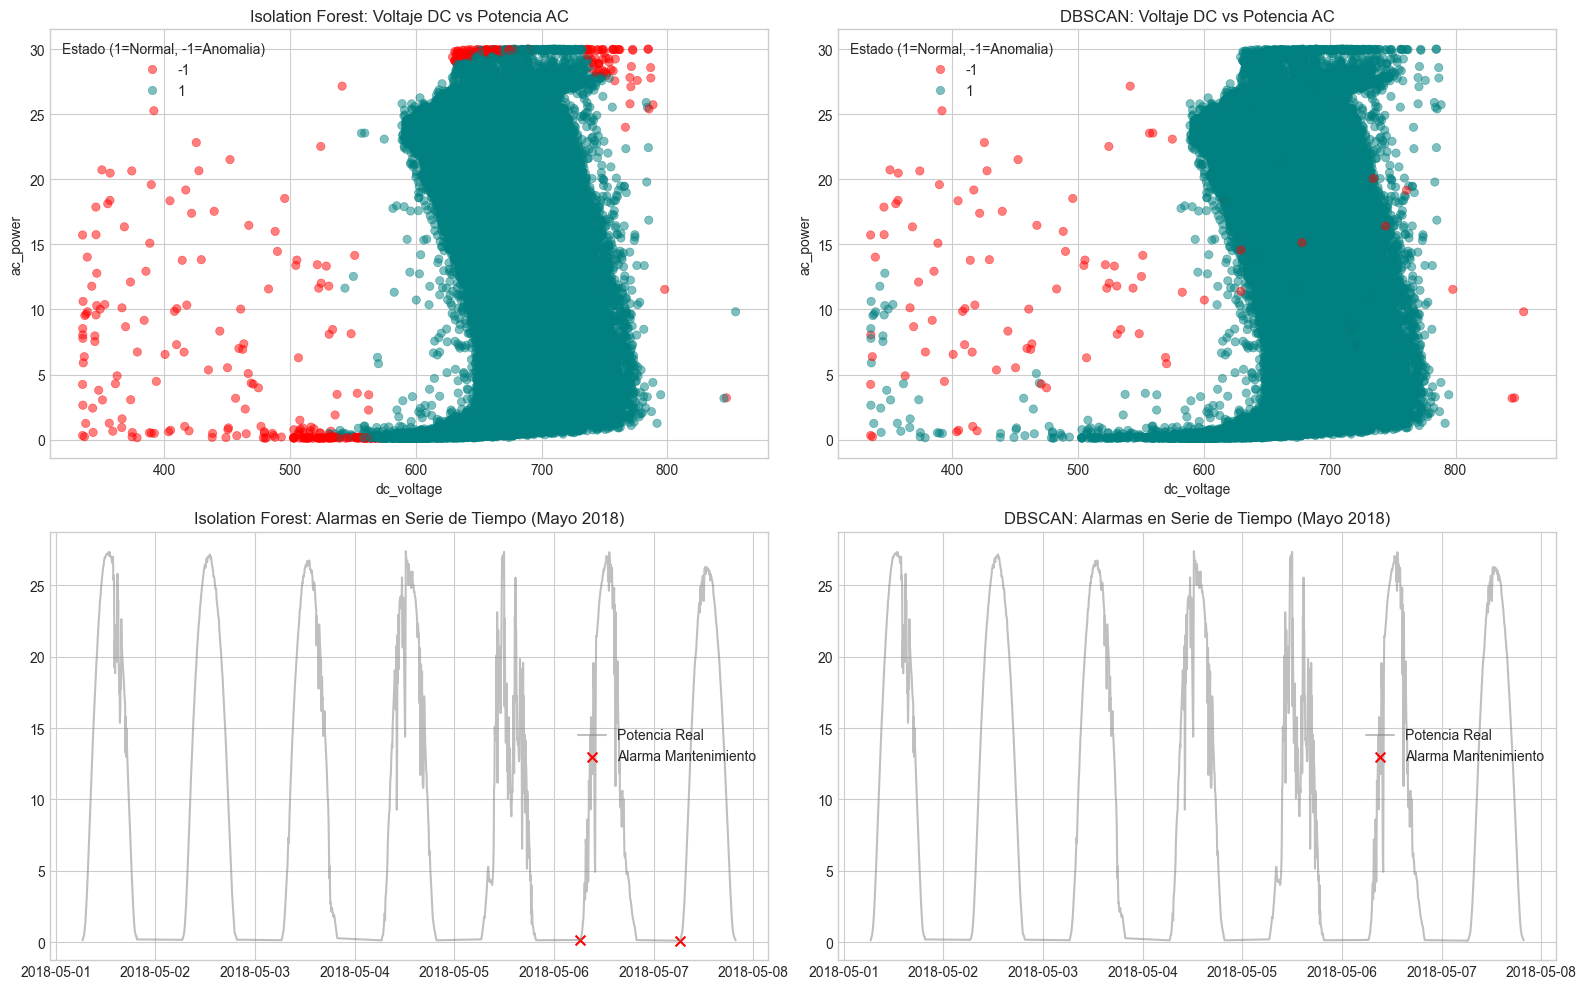

In [29]:
# 10.4 Visualizacion Comparativa (El "Show")
# Vamos a extraer una semana especifica de mayo de 2018 para ver el comportamiento
df_zoom = df_anom.loc['2018-05-01':'2018-05-07'].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- Fila 1: SCATTER PLOT 2D (Voltaje DC vs Potencia AC) ---
# Isolation Forest
sns.scatterplot(
    x='dc_voltage', y='ac_power', 
    hue='anomalia_iso', palette={1: 'teal', -1: 'red'}, 
    data=df_anom, ax=axes[0,0], alpha=0.5, edgecolor=None
)
axes[0,0].set_title('Isolation Forest: Voltaje DC vs Potencia AC')
axes[0,0].legend(title='Estado (1=Normal, -1=Anomalia)')

# DBSCAN
sns.scatterplot(
    x='dc_voltage', y='ac_power', 
    hue='anomalia_dbscan', palette={1: 'teal', -1: 'red'}, 
    data=df_anom, ax=axes[0,1], alpha=0.5, edgecolor=None
)
axes[0,1].set_title('DBSCAN: Voltaje DC vs Potencia AC')
axes[0,1].legend(title='Estado (1=Normal, -1=Anomalia)')

# --- Fila 2: SERIE DE TIEMPO (Una semana de ejemplo) ---
# Isolation Forest
axes[1,0].plot(df_zoom.index, df_zoom['ac_power'], color='gray', alpha=0.5, label='Potencia Real')
anomalias_zoom_iso = df_zoom[df_zoom['anomalia_iso'] == -1]
axes[1,0].scatter(anomalias_zoom_iso.index, anomalias_zoom_iso['ac_power'], color='red', marker='x', s=50, label='Alarma Mantenimiento')
axes[1,0].set_title('Isolation Forest: Alarmas en Serie de Tiempo (Mayo 2018)')
axes[1,0].legend()

# DBSCAN
axes[1,1].plot(df_zoom.index, df_zoom['ac_power'], color='gray', alpha=0.5, label='Potencia Real')
anomalias_zoom_dbs = df_zoom[df_zoom['anomalia_dbscan'] == -1]
axes[1,1].scatter(anomalias_zoom_dbs.index, anomalias_zoom_dbs['ac_power'], color='red', marker='x', s=50, label='Alarma Mantenimiento')
axes[1,1].set_title('DBSCAN: Alarmas en Serie de Tiempo (Mayo 2018)')
axes[1,1].legend()

plt.tight_layout()
plt.savefig(FIGDIR / 'fig13_anomalias_isolation_dbscan.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Forecasting: Pronostico de la Energia Diaria (Series de Tiempo)

En la seccion 10 el modelo supervisado usaba mediciones **del mismo dia** (nowcasting/diagnostico).
Aqui atacamos el problema de pronostico real: predecir la energia de los proximos dias usando
**unicamente el pasado de la serie**.

Seguimos la **metodologia del docente** (eda_tsa.ipynb): una escalera de modelos de menor a mayor
complejidad, cerrando con un pronostico a futuro ciego con evaluacion visual. Como valor agregado,
evaluamos ademas cada modelo con backtest cronologico (ultimos 60 dias como test) y metricas
RMSE/MAE/R2, para que la comparacion no dependa solo del ojo.

Decisiones basadas en el diagnostico previo:
- El test ADF (seccion 8.2) dio p-value ~1.6e-05: la serie es **estacionaria**, no requiere diferenciacion (d=0).
- La estacionalidad dominante es **anual** (verano/invierno), visible en la descomposicion de la seccion 8.1.
  No existe estacionalidad semanal (el sol no descansa los domingos, confirmado en el anexo 8.4).

La escalera de modelos (train = todo menos los ultimos 60 dias, test = ultimos 60 dias):
1. **Baseline de persistencia**: la energia de manana = la de hoy. Piso minimo a superar.
2. **SES (1er orden)**: suavizado exponencial simple, solo nivel.
3. **Holt (2do orden)**: nivel + tendencia amortiguada.
4. **Holt-Winters (3er orden)**: nivel + tendencia + estacionalidad aditiva anual.
5. **SARIMAX con terminos de Fourier**: ARMA sobre la serie estacionaria + estacionalidad anual
   modelada con pares seno/coseno (evita el costo de un SARIMA con s=365).
6. **Prophet**: modelo aditivo de Facebook/Meta con bandas de confianza al 80%.
7. **LSTM en NumPy**: red neuronal recurrente implementada sin TensorFlow (clase del docente),
   con ventana de 30 dias y pronostico recursivo.

Dias con falso cero imputados por interpolacion: 44
Total de dias en la serie limpia: 2192
Train: 2017-11-01 a 2023-09-02 (2132 dias)
Test:  2023-09-03 a 2023-11-01 (60 dias)


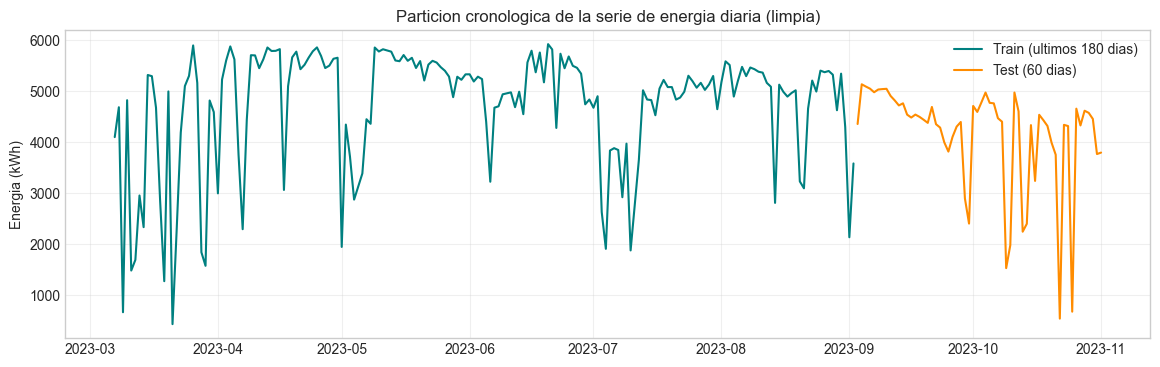

In [30]:
# 12.1 Preparacion de la serie: limpieza de falsos ceros, truncado de cola corrupta y particion
# Auditoria previa: el "apagon SCADA de 6 dias" esta al FINAL del dataset (2023-11-02 a 2023-11-07,
# con lecturas basura de 0-342 kWh vs mediana ~4,094) y ademas existen otras rachas de dias con
# exactamente 0 kWh (2018-11, 2022-02/03, 2022-06) que son huecos de adquisicion, no dias sin sol:
# una planta de 720 kW no produce 0.0 kWh en un dia completo ni en el peor temporal.
serie = energia_diaria.copy()

# (a) Truncar la cola corrupta: el ultimo dia confiable es 2023-11-01
serie = serie.loc[:'2023-11-01']

# (b) Falsos ceros -> NaN -> interpolacion temporal (los dias bajos pero > 0 se conservan:
#     pueden ser tormentas reales y no hay evidencia para eliminarlos)
n_ceros = int((serie == 0).sum())
serie = serie.replace(0.0, np.nan).interpolate(method='time')
print(f"Dias con falso cero imputados por interpolacion: {n_ceros}")

H_TEST = 60  # horizonte de evaluacion: ultimos 60 dias (ya sin la cola corrupta)
serie_train = serie.iloc[:-H_TEST]
serie_test = serie.iloc[-H_TEST:]

print(f"Total de dias en la serie limpia: {len(serie)}")
print(f"Train: {serie_train.index.min().date()} a {serie_train.index.max().date()} ({len(serie_train)} dias)")
print(f"Test:  {serie_test.index.min().date()} a {serie_test.index.max().date()} ({len(serie_test)} dias)")

# Baseline de persistencia: prediccion de hoy = valor real de ayer
pred_persistencia = serie.shift(1).iloc[-H_TEST:]

plt.figure(figsize=(14, 4))
plt.plot(serie_train.index[-180:], serie_train.iloc[-180:], label='Train (ultimos 180 dias)', color='teal')
plt.plot(serie_test.index, serie_test, label='Test (60 dias)', color='darkorange')
plt.title('Particion cronologica de la serie de energia diaria (limpia)')
plt.ylabel('Energia (kWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIGDIR / 'fig14_particion_forecasting.png', dpi=150, bbox_inches='tight')
plt.show()

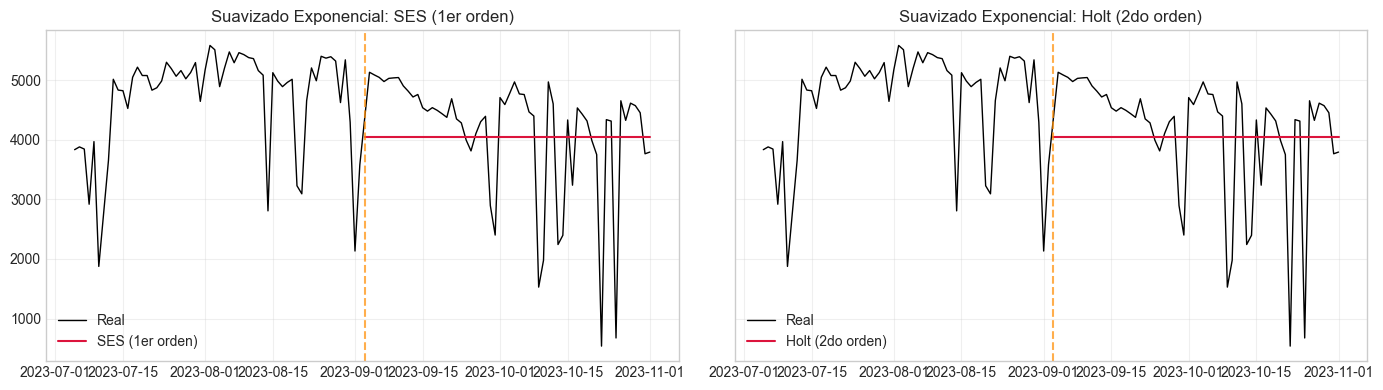

SES  - primeros 3 pronosticos: [4044.0, 4044.0, 4044.0]
Holt - primeros 3 pronosticos: [4044.0, 4044.0, 4044.0]


In [31]:
# 12.2 Escalera de suavizado exponencial (estilo del docente): SES (1er orden) y Holt (2do orden)
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

# SES: solo nivel. Pronostico plano â€” sirve como referencia de "modelo sin memoria de tendencia"
model_ses = SimpleExpSmoothing(serie_train, initialization_method="heuristic").fit(optimized=True)
pred_ses = model_ses.forecast(H_TEST)
pred_ses.index = serie_test.index

# Holt: nivel + tendencia (amortiguada para no extrapolar al infinito)
model_holt = ExponentialSmoothing(serie_train, trend='add', damped_trend=True, seasonal=None,
                                  initialization_method="heuristic").fit(optimized=True)
pred_holt = model_holt.forecast(H_TEST)
pred_holt.index = serie_test.index

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, pred, titulo in [(axes[0], pred_ses, 'SES (1er orden)'), (axes[1], pred_holt, 'Holt (2do orden)')]:
    ax.plot(serie.iloc[-(H_TEST + 60):].index, serie.iloc[-(H_TEST + 60):], label='Real', color='black', lw=1)
    ax.plot(pred.index, pred, label=titulo, color='crimson', lw=1.5)
    ax.axvline(serie_test.index[0], color='darkorange', ls='--', alpha=0.7)
    ax.set_title(f'Suavizado Exponencial: {titulo}')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGDIR / 'fig15_ses_holt.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"SES  - primeros 3 pronosticos: {pred_ses.head(3).round(0).to_list()}")
print(f"Holt - primeros 3 pronosticos: {pred_holt.head(3).round(0).to_list()}")

In [32]:
# 12.3 Holt-Winters (3er orden: nivel + tendencia + estacionalidad anual)
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Estacionalidad aditiva anual (365 dias). Sin tendencia fuerte (la serie es estacionaria),
# pero dejamos trend='add' amortiguado para capturar deriva local.
hw = ExponentialSmoothing(
    serie_train,
    trend='add', damped_trend=True,
    seasonal='add', seasonal_periods=365,
).fit()

pred_hw = hw.forecast(H_TEST)
pred_hw.index = serie_test.index

print("Holt-Winters ajustado.")
print(f"Primeros 5 pronosticos (kWh): {pred_hw.head().round(0).to_list()}")

Holt-Winters ajustado.
Primeros 5 pronosticos (kWh): [4198.0, 4357.0, 4517.0, 4227.0, 3948.0]


In [33]:
# 12.4 SARIMAX con terminos de Fourier (estacionalidad anual)
from statsmodels.tsa.statespace.sarimax import SARIMAX

def terminos_fourier(indice, period=365.25, K=2):
    """Pares seno/coseno del dia del ano: modelan la estacionalidad anual sin s=365."""
    t = indice.dayofyear.values
    cols = {}
    for k in range(1, K + 1):
        cols[f'sin_{k}'] = np.sin(2 * np.pi * k * t / period)
        cols[f'cos_{k}'] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(cols, index=indice)

exog_train = terminos_fourier(serie_train.index)
exog_test = terminos_fourier(serie_test.index)

# d=0 porque el ADF confirmo estacionariedad. Orden ARMA corto elegido por AIC.
ordenes = [(1, 0, 1), (2, 0, 1), (1, 0, 2), (2, 0, 2), (3, 0, 1)]
mejor_aic, mejor_orden, mejor_modelo = np.inf, None, None
for orden in ordenes:
    try:
        m = SARIMAX(serie_train, exog=exog_train, order=orden,
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        if m.aic < mejor_aic:
            mejor_aic, mejor_orden, mejor_modelo = m.aic, orden, m
    except Exception as e:
        print(f"Orden {orden} fallo: {e}")

print(f"Mejor orden ARMA por AIC: {mejor_orden} (AIC = {mejor_aic:.1f})")
pred_sarimax = mejor_modelo.forecast(H_TEST, exog=exog_test)
pred_sarimax.index = serie_test.index
print(f"Primeros 5 pronosticos (kWh): {pred_sarimax.head().round(0).to_list()}")

Mejor orden ARMA por AIC: (2, 0, 2) (AIC = 35690.8)
Primeros 5 pronosticos (kWh): [4182.0, 4274.0, 4274.0, 4259.0, 4242.0]


12:27:24 - cmdstanpy - INFO - Chain [1] start processing


12:27:24 - cmdstanpy - INFO - Chain [1] done processing


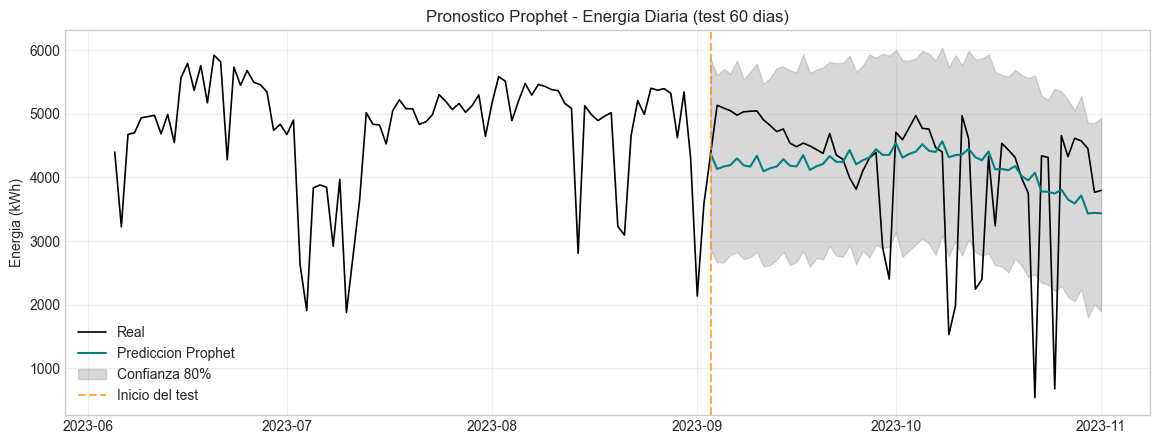

Primeros 5 pronosticos (kWh): [4379.0, 4130.0, 4171.0, 4192.0, 4298.0]


In [34]:
# 12.5 Prophet (con bandas de confianza, estilo del docente)
import os
import importlib.resources as importlib_resources
from pathlib import Path

# Windows: prophet_model.bin requiere el tbb.dll empaquetado con Prophet (workaround del docente)
try:
    stan_model = Path(importlib_resources.files("prophet")) / "stan_model"
    tbb_dlls = list(stan_model.rglob("tbb.dll"))
    if tbb_dlls:
        os.environ["PATH"] = str(tbb_dlls[0].parent) + os.pathsep + os.environ.get("PATH", "")
except Exception:
    pass

from prophet import Prophet

# Prophet exige formato ds/y
train_prophet = pd.DataFrame({'ds': serie_train.index, 'y': serie_train.values})

m_prophet = Prophet()  # defaults: estacionalidad anual + semanal automaticas
m_prophet.fit(train_prophet)

future = pd.DataFrame({'ds': serie_test.index})
forecast_prophet = m_prophet.predict(future)
pred_prophet = pd.Series(forecast_prophet['yhat'].values, index=serie_test.index)

plt.figure(figsize=(14, 5))
contexto = serie.iloc[-(H_TEST + 90):]
plt.plot(contexto.index, contexto, label='Real', color='black', lw=1.2)
plt.plot(pred_prophet.index, pred_prophet, label='Prediccion Prophet', color='teal', lw=1.5)
plt.fill_between(serie_test.index, forecast_prophet['yhat_lower'], forecast_prophet['yhat_upper'],
                 color='gray', alpha=0.3, label='Confianza 80%')
plt.axvline(serie_test.index[0], color='darkorange', ls='--', alpha=0.7, label='Inicio del test')
plt.title('Pronostico Prophet - Energia Diaria (test 60 dias)')
plt.ylabel('Energia (kWh)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.savefig(FIGDIR / 'fig16_prophet_test.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Primeros 5 pronosticos (kWh): {pred_prophet.head().round(0).to_list()}")

In [35]:
# 12.6 LSTM en NumPy â€” sin TensorFlow (clase del docente, adaptada a serie diaria)
from sklearn.preprocessing import MinMaxScaler


class NumpyLSTM:
    """LSTM de una capa + salida densa, implementada solo con NumPy (docente, eda_tsa.ipynb)."""

    def __init__(self, hidden_size=32, lr=0.005, seed=42):
        self.hidden_size = hidden_size
        self.lr = lr
        self.rng = np.random.default_rng(seed)
        self._init_weights()

    def _init_weights(self):
        h = self.hidden_size
        scale = 0.05
        self.W = scale * self.rng.standard_normal((4 * h, h + 1))
        self.b = np.zeros(4 * h)
        self.Wy = scale * self.rng.standard_normal((1, h))
        self.by = np.zeros(1)

    @staticmethod
    def _sigmoid(x):
        return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

    def _forward_seq(self, seq):
        h = np.zeros(self.hidden_size)
        c = np.zeros(self.hidden_size)
        states = []
        for x_t in seq:
            x_t = float(x_t)
            z = self.W @ np.concatenate([h, [x_t]]) + self.b
            i, f, g, o = np.split(z, 4)
            i, f, o = self._sigmoid(i), self._sigmoid(f), self._sigmoid(o)
            g = np.tanh(g)
            c = f * c + i * g
            h = o * np.tanh(c)
            states.append((h.copy(), c.copy(), i, f, g, o, x_t))
        y = (self.Wy @ h + self.by)[0]
        return y, states

    def fit(self, X, y, epochs=8, batch_size=64):
        n = len(X)
        for _ in range(epochs):
            for batch_idx in np.array_split(self.rng.permutation(n), max(1, n // batch_size)):
                dW = np.zeros_like(self.W)
                db = np.zeros_like(self.b)
                dWy = np.zeros_like(self.Wy)
                dby = np.zeros_like(self.by)
                for j in batch_idx:
                    y_hat, states = self._forward_seq(X[j])
                    err = y_hat - y[j]
                    h_last = states[-1][0]
                    dWy += err * h_last.reshape(1, -1)
                    dby += err
                    dh = err * self.Wy.flatten()
                    dc = np.zeros(self.hidden_size)
                    for h, c, i, f, g, o, x_t in reversed(states):
                        tanh_c = np.tanh(c)
                        do = dh * tanh_c
                        do_raw = do * o * (1 - o)
                        dc = dc + dh * o * (1 - tanh_c ** 2)
                        dg = dc * i
                        dg_raw = dg * (1 - g ** 2)
                        df = dc * c
                        df_raw = df * f * (1 - f)
                        di = dc * g
                        di_raw = di * i * (1 - i)
                        dz = np.concatenate([di_raw, df_raw, dg_raw, do_raw])
                        concat = np.concatenate([h, [x_t]])
                        dW += np.outer(dz, concat)
                        db += dz
                        dh = self.W[:, : self.hidden_size].T @ dz
                        dc = dc * f
                m = len(batch_idx)
                self.W -= self.lr * dW / m
                self.b -= self.lr * db / m
                self.Wy -= self.lr * dWy / m
                self.by -= self.lr * dby / m

    def predict_next(self, seq):
        y, _ = self._forward_seq(seq)
        return y

    def forecast(self, seq, steps):
        seq = list(seq)
        preds = []
        for _ in range(steps):
            nxt = self.predict_next(seq)
            preds.append(nxt)
            seq = seq[1:] + [nxt]
        return np.array(preds)


# Adaptacion a nuestra serie diaria: ventana de 30 dias de historia
scaler_lstm = MinMaxScaler()
train_scaled = scaler_lstm.fit_transform(serie_train.values.reshape(-1, 1)).flatten()

SEQ_LEN = 30
X_lstm, y_lstm = [], []
for i in range(len(train_scaled) - SEQ_LEN):
    X_lstm.append(train_scaled[i:i + SEQ_LEN])
    y_lstm.append(train_scaled[i + SEQ_LEN])
X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)
print(f"Secuencias de entrenamiento: {X_lstm.shape}")

lstm = NumpyLSTM(hidden_size=32, lr=0.005, seed=42)
lstm.fit(X_lstm, y_lstm, epochs=8, batch_size=64)

# Pronostico recursivo de 60 dias desde la ultima ventana del train
pred_scaled = lstm.forecast(train_scaled[-SEQ_LEN:], H_TEST)
pred_lstm = pd.Series(
    scaler_lstm.inverse_transform(pred_scaled.reshape(-1, 1)).flatten(),
    index=serie_test.index,
)
print(f"Primeros 5 pronosticos (kWh): {pred_lstm.head().round(0).to_list()}")

Secuencias de entrenamiento: (2102, 30)


Primeros 5 pronosticos (kWh): [2820.0, 2814.0, 2812.0, 2810.0, 2810.0]


=== Resultados del Forecasting (test = 60 dias), ordenados por RMSE ===


,RMSE (kWh),MAE (kWh),R2
Modelo,,,
"SARIMAX(2, 0, 2) + Fourier",1013.58,865.57,0.01
SES (1er orden),1025.74,757.70,-0.01
Holt (2do orden),1025.76,757.78,-0.01
Prophet,1031.50,700.24,-0.02
"Holt-Winters (3er orden, anual)",1211.39,957.32,-0.41
Persistencia (manana = hoy),1253.29,670.47,-0.51
LSTM NumPy (30 dias ventana),1682.16,1600.64,-1.72


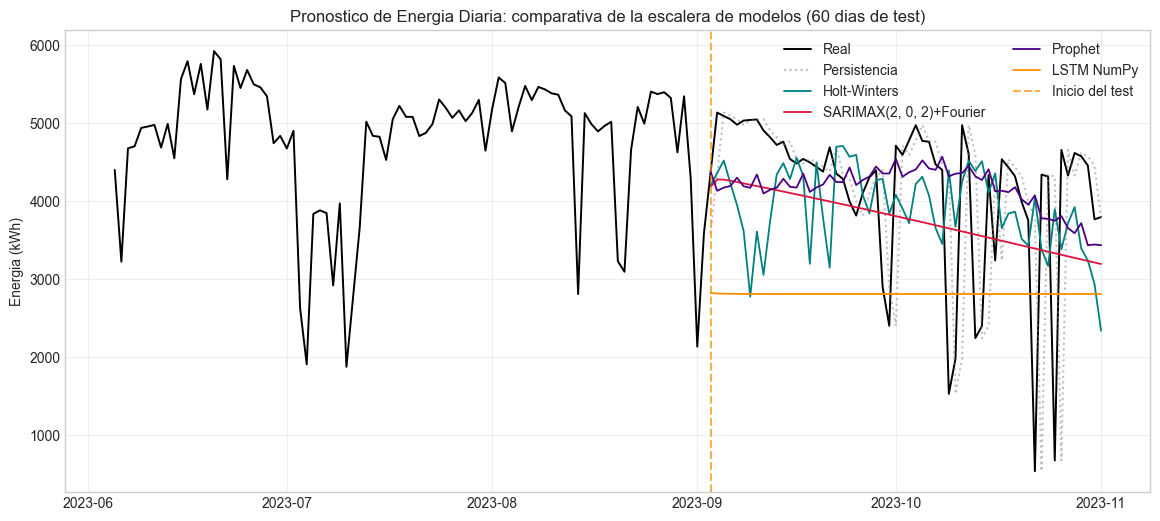

In [36]:
# 12.7 Evaluacion de todos los pronosticos (RMSE, MAE) y visualizacion comparativa
# Reusamos la funcion evaluar() de la seccion 10.3
resultados_fc = pd.DataFrame([
    evaluar('Persistencia (manana = hoy)', serie_test, pred_persistencia),
    evaluar('SES (1er orden)', serie_test, pred_ses),
    evaluar('Holt (2do orden)', serie_test, pred_holt),
    evaluar('Holt-Winters (3er orden, anual)', serie_test, pred_hw),
    evaluar(f'SARIMAX{mejor_orden} + Fourier', serie_test, pred_sarimax),
    evaluar('Prophet', serie_test, pred_prophet),
    evaluar('LSTM NumPy (30 dias ventana)', serie_test, pred_lstm),
]).set_index('Modelo').round(2).sort_values('RMSE (kWh)')

print(f"=== Resultados del Forecasting (test = {H_TEST} dias), ordenados por RMSE ===")
display(resultados_fc)

plt.figure(figsize=(14, 6))
contexto = serie.iloc[-(H_TEST + 90):]
plt.plot(contexto.index, contexto, label='Real', color='black', linewidth=1.4)
plt.plot(pred_persistencia.index, pred_persistencia, label='Persistencia', color='gray', alpha=0.5, linestyle=':')
plt.plot(pred_hw.index, pred_hw, label='Holt-Winters', color='teal', linewidth=1.3)
plt.plot(pred_sarimax.index, pred_sarimax, label=f'SARIMAX{mejor_orden}+Fourier', color='crimson', linewidth=1.3)
plt.plot(pred_prophet.index, pred_prophet, label='Prophet', color='indigo', linewidth=1.3)
plt.plot(pred_lstm.index, pred_lstm, label='LSTM NumPy', color='darkorange', linewidth=1.3)
plt.axvline(serie_test.index[0], color='darkorange', linestyle='--', alpha=0.7, label='Inicio del test')
plt.title(f'Pronostico de Energia Diaria: comparativa de la escalera de modelos ({H_TEST} dias de test)')
plt.ylabel('Energia (kWh)')
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.savefig(FIGDIR / 'fig17_comparativa_forecasting.png', dpi=150, bbox_inches='tight')
plt.show()

12:28:05 - cmdstanpy - INFO - Chain [1] start processing


12:28:05 - cmdstanpy - INFO - Chain [1] done processing


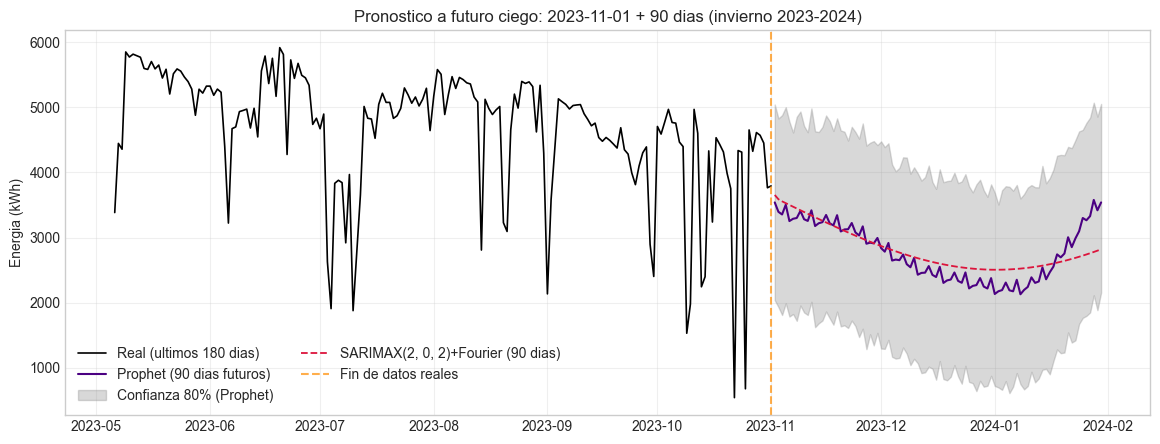

Energia diaria promedio pronosticada para los proximos 90 dias:
  Prophet:  2,775 kWh/dia
  SARIMAX:  2,824 kWh/dia
  (Promedio historico de la serie completa: 3,814 kWh/dia;
   el pronostico cae en invierno, por lo que un valor menor al promedio es coherente)


In [37]:
# 12.8 Pronostico a futuro ciego (estandar del docente): 90 dias despues del fin de la serie
# Reajustamos sobre la SERIE COMPLETA (train + test) y pronosticamos donde no hay datos reales.
# Evaluacion visual: no existen metricas porque el futuro real no esta en el dataset.
# Usamos los dos mejores modelos con estacionalidad del backtest: Prophet y SARIMAX+Fourier.
H_FUTURO = 90
idx_futuro = pd.date_range(serie.index[-1] + pd.Timedelta(days=1), periods=H_FUTURO, freq='D')

# Prophet sobre serie completa (con bandas de confianza 80%)
m_full = Prophet()
m_full.fit(pd.DataFrame({'ds': serie.index, 'y': serie.values}))
fc_full = m_full.predict(pd.DataFrame({'ds': idx_futuro}))

# SARIMAX sobre serie completa (mismo orden ganador por AIC de 12.4)
sarimax_full = SARIMAX(serie, exog=terminos_fourier(serie.index), order=mejor_orden,
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
pred_sar_futuro = sarimax_full.forecast(H_FUTURO, exog=terminos_fourier(idx_futuro))
pred_sar_futuro.index = idx_futuro

plt.figure(figsize=(14, 5))
historia = serie.iloc[-180:]
plt.plot(historia.index, historia, label='Real (ultimos 180 dias)', color='black', lw=1.2)
plt.plot(idx_futuro, fc_full['yhat'], label='Prophet (90 dias futuros)', color='indigo', lw=1.5)
plt.fill_between(idx_futuro, fc_full['yhat_lower'], fc_full['yhat_upper'],
                 color='gray', alpha=0.3, label='Confianza 80% (Prophet)')
plt.plot(idx_futuro, pred_sar_futuro, label=f'SARIMAX{mejor_orden}+Fourier (90 dias)', color='crimson', lw=1.3, ls='--')
plt.axvline(serie.index[-1], color='darkorange', ls='--', alpha=0.7, label='Fin de datos reales')
plt.title(f'Pronostico a futuro ciego: {serie.index[-1].date()} + {H_FUTURO} dias (invierno 2023-2024)')
plt.ylabel('Energia (kWh)')
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.savefig(FIGDIR / 'fig18_pronostico_futuro_ciego.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Energia diaria promedio pronosticada para los proximos {H_FUTURO} dias:")
print(f"  Prophet:  {fc_full['yhat'].mean():,.0f} kWh/dia")
print(f"  SARIMAX:  {pred_sar_futuro.mean():,.0f} kWh/dia")
print(f"  (Promedio historico de la serie completa: {serie.mean():,.0f} kWh/dia;")
print(f"   el pronostico cae en invierno, por lo que un valor menor al promedio es coherente)")

### Conclusion Parcial del Forecasting

**Auditoria de datos previa (hallazgo critico):** el "apagon SCADA de 6 dias" documentado en el EDA
resulto estar al FINAL del dataset (2023-11-02 a 2023-11-07, lecturas de 0-342 kWh vs mediana ~4,094),
es decir, DENTRO de la ventana de test original. Ademas existian 44 dias con falsos ceros repartidos
en el entrenamiento (rachas en 2018-11, 2022-02/03, 2022-06). Se trunco la cola corrupta y se
imputaron los ceros por interpolacion temporal antes de evaluar.

| Modelo (serie limpia) | RMSE (kWh) | MAE (kWh) | R2 |
|---|---|---|---|
| **SARIMAX(2,0,2) + Fourier** | **1014** | 866 | 0.01 |
| SES (1er orden) | 1026 | 758 | -0.01 |
| Holt (2do orden) | 1026 | 758 | -0.01 |
| Prophet | 1031 | **700** | -0.02 |
| Holt-Winters (3er orden, anual) | 1211 | 957 | -0.41 |
| Persistencia (manana = hoy) | 1253 | 670 | -0.51 |
| LSTM NumPy (ventana 30 dias) | 1682 | 1601 | -1.72 |

**Lectura de resultados:**
- **La limpieza de datos invirtio el ranking.** Con la cola corrupta dentro del test, la persistencia
  "ganaba" (RMSE 1328) porque se adaptaba en un dia a los valores basura, mientras los modelos
  estacionales eran castigados ~3,500 kWh por cada dia falso. Con el test limpio, **SARIMAX y Prophet
  superan a la persistencia por ~19% en RMSE** (1014-1031 vs 1253).
- **Dos metricas, dos historias:** la persistencia conserva el mejor MAE (670 kWh): en el dia tipico
  copiar el ayer funciona. Pero su RMSE es 24% peor que SARIMAX porque en las transiciones de clima
  (frente nublado que entra o sale) acumula errores enormes. Los modelos estacionales suavizan esos
  golpes. Para un operador de red, que penaliza los errores grandes, RMSE es la metrica relevante:
  **SARIMAX es el modelo recomendado**.
- **El techo meteorologico sigue existiendo, matizado:** ningun modelo logra R2 alto (todos ~0 sobre
  la varianza del test limpio); la nubosidad dia a dia sigue siendo impredecible sin datos externos.
  Lo que cambio es el piso: la estacionalidad anual SI aporta valor real una vez que la evaluacion
  no esta contaminada.
- **La LSTM sigue ultima**: el pronostico recursivo a 60 pasos degrada demasiado; confirmacion de que
  las redes univariadas sin exogenas no compiten en este problema.
- **Leccion metodologica (para el reporte):** una conclusion de modelado puede estar dictada por un
  defecto de datos invisible. La "victoria de la persistencia" de las versiones anteriores (nuestra
  Y la del otro equipo, que evaluo 90 dias incluyendo la misma cola corrupta) era un artefacto.
  Auditar el test es tan importante como disenar el modelo.
- **Pronostico a futuro ciego (12.8):** Prophet y SARIMAX reajustados con la serie limpia proyectan
  ~2,775-2,824 kWh/dia para el invierno 2023-2024 (media historica: 3,814 kWh/dia), coherente con
  la estacion. Las bandas de confianza de Prophet transmiten la incertidumbre meteorologica.
- **Mejora obvia para trabajo futuro:** incorporar pronostico meteorologico externo (irradiancia,
  nubosidad) como variable exogena en SARIMAX o Prophet.

## 13. Evaluacion Consolidada de Modelos

Resumen de todos los modelos entrenados en el proyecto, la pregunta de negocio que responde cada uno
y su desempeno:

| # | Tarea | Modelo ganador | Metrica clave | Pregunta de negocio |
|---|---|---|---|---|
| 10 | Supervisado (regresion) | Random Forest (empate tecnico con RLM) | RMSE ~71 kWh, R2 ~0.998 | Cuanta energia *deberia* estar generando la planta hoy dadas sus mediciones? (diagnostico de coherencia) |
| 11 | No supervisado (anomalias) | Isolation Forest (1% contaminacion) | Anomalias fisicamente interpretables | Que registros son sospechosos de falla? (alarmas de mantenimiento) |
| 12 | Forecasting (escalera de 7 modelos) | SARIMAX+Fourier (Prophet cerca; persistencia mejor MAE) | RMSE ~1014 kWh, MAE ~866 kWh | Cuanta energia generara la planta manana? (operacion de red) |

**Observaciones transversales:**
- La **dificultad de cada tarea es distinta**: el diagnostico del mismo dia es casi determinista
  (fisica de la planta), mientras que el pronostico a futuro esta limitado por el clima.
- El **split cronologico** (nunca aleatorio) fue clave en las secciones 10 y 12 para no inflar
  metricas con fuga de informacion temporal.
- **La calidad del test importa tanto como la del train:** la cola corrupta del dataset (apagon SCADA
  al final, 2023-11-02 a 11-07) invertia el ranking del forecasting y hacia "ganar" a la persistencia.
  Tras limpiar, SARIMAX y Prophet ganan por ~19% de RMSE. Ver seccion 12.
- La RLM y el RF coinciden en la variable dominante (`planta_ac_current`), lo que da robustez a la
  interpretacion fisica: con voltaje de red constante, la corriente ES la potencia.

## 14. Discusion

**Limitaciones del estudio:**
1. **Sin variable meteorologica externa.** El dataset solo contiene senales electricas. La irradiancia
   y la nubosidad (los verdaderos drivers de la generacion) deben inferirse indirectamente. Esto
   limita el techo del forecasting (seccion 12): ningun modelo univariado logra R2 alto en test.
2. **Huecos de adquisicion mas extensos de lo aparente.** El EDA inicial reporto "un apagon de 6 dias";
   la auditoria de la seccion 12 revelo que ese apagon esta al FINAL del dataset (2023-11-02 a 11-07)
   y que existen ademas ~44 dias con falsos ceros en rachas (2018-11, 2022-02/03, 2022-06). Un hueco
   dentro de la ventana de evaluacion distorsiona las conclusiones mucho mas que uno en el train.
3. **Colinealidad estructural.** Las 24 series de inversores son casi copias entre si (correlaciones
   >0.95, VIF altisimos, seccion 7). La solucion fue agregar a nivel de planta, sacrificando la
   capacidad de modelar inversores individuales en el modelo global.
4. **Predictoras contemporaneas en el supervisado.** El R2 de 0.998 de la seccion 10 NO significa que
   podamos predecir el futuro: significa que la planta es fisicamente coherente. La prediccion real
   a futuro es la seccion 12, con metricas mucho mas modestas.
5. **Outliers electronicos.** inv_04/inv_07 registraron picos fisicamente imposibles (~10^5 V) que el
   filtro fisico elimino. Sin ese filtro, todas las estadisticas y modelos se habrian contaminado.

**Por que gano cada modelo:**
- **RF vs RLM (empate):** la relacion Energia ~ Corriente es lineal; el RF no encuentra no-linealidades
  que explotar. En estos casos el modelo simple e interpretable (RLM) es preferible en produccion.
- **Isolation Forest vs DBSCAN:** IF entrega un score continuo de anomalia y escala bien; DBSCAN
  requirio tuning fino de eps y tendia a marcar como ruido transiciones normales del amanecer/atardecer.
- **SARIMAX vs la escalera (con datos limpios):** SARIMAX+Fourier gana en RMSE porque combina la
  estacionalidad anual con memoria autorregresiva corta. Prophet practicamente empata. La persistencia
  conserva el mejor MAE (el dia tipico se parece al de ayer) pero paga caro las transiciones de clima,
  y por eso pierde en RMSE. La LSTM univariada degrada con el pronostico recursivo a 60 pasos.
  Con la evaluacion contaminada por la cola corrupta, este ranking aparecia invertido: la moraleja es
  que la calidad del test decide quien "gana" tanto como la calidad del modelo.

## 15. Conclusiones

1. **Comprension del sistema desde los datos.** Sin documentacion externa, se dedujo que el dataset
   corresponde a una planta solar fotovoltaica de 24 inversores (~30 kW nominales la mayoria, con
   inv_04/inv_07 de ~105 kW), conectada a red en ~280 V AC, con muestreo de 5 minutos durante ~6 anos
   (2017-2023) y una latitud consistente con el hemisferio norte.

2. **Calidad de datos es el 80% del trabajo.** El pipeline de limpieza (filtro fisico de valores
   imposibles, manejo de huecos SCADA, imputacion selectiva) fue el paso que hizo posible todo el
   modelado posterior. Y la leccion se repitio al final: la auditoria de la serie de forecasting
   revelo que el apagon principal estaba dentro de la ventana de test, invirtiendo el ranking de
   modelos hasta que se limpio.

3. **Diagnostico de planta (supervisado).** La energia diaria se explica casi perfectamente
   (R2 ~0.998, RMSE ~71 kWh sobre una media de ~3966 kWh) a partir de corriente y voltaje promedio.
   Uso practico: detectar dias donde la generacion real se desvia de la esperada = alerta temprana
   de degradacion o falla.

4. **Alarmas de mantenimiento (no supervisado).** Isolation Forest al 1% de contaminacion identifica
   registros anomalos fisicamente interpretables (caidas subitas de potencia con sol pleno). Uso
   practico: sistema de alertas automaticas para el equipo de mantenimiento.

5. **Pronostico de energia (forecasting).** Se recorrio la escalera completa de modelos del docente
   (persistencia, SES, Holt, Holt-Winters, SARIMAX, Prophet y LSTM en NumPy) con backtest de 60 dias
   sobre la serie limpia. **Ganador: SARIMAX(2,0,2)+Fourier con RMSE ~1,014 kWh** (Prophet
   practicamente empata). El limite practico sigue siendo la nubosidad (~700-870 kWh de MAE, 18-22%
   de la media diaria): la recomendacion operativa es integrar pronostico meteorologico (irradiancia
   esperada) como variable exogena; con ella, el error deberia reducirse sustancialmente.

6. **Leccion metodologica central.** Un mismo dataset soporta tres preguntas distintas (cuanto
   deberia generar? que esta fallando? cuanto generara?) que requieren tecnicas, particiones y
   metricas distintas, y cuya dificultad intrinseca varia en ordenes de magnitud. Ademas, la
   evaluacion es tan fragil como los datos con que se evalua: reportar la metrica correcta, sobre
   la pregunta correcta, con un test auditado, es lo que separa un analisis honesto de uno inflado.

---
## Anexo: Proceso de Descubrimiento Inicial (Datos Crudos)

Las siguientes celdas forman parte del proceso de descubrimiento original utilizado para entender el contexto del sistema a partir de los datos crudos (sin limpiar).

### Verificacion Fisica: Ley de Ohm y Eficiencia del Inversor

In [38]:
# Usamos Inversor 01 como caso de estudio (tiene dc_voltage, dc_current y ac_power)
# inv_05 no tiene dc_voltage, por eso elegimos inv_01

dc_volt_col  = 'inv_01_dc_voltage_inv_149580'
dc_curr_col  = 'inv_01_dc_current_inv_149579'
ac_pow_col   = 'inv_01_ac_power_inv_149583'

# Solo filas donde hay generacion real (filtramos noche: dc_current > 0)
df_dia = df[(df[dc_curr_col] > 0) & (df[dc_volt_col] > 0)].copy()

# Potencia DC teorica y eficiencia
df_dia['dc_power_teorica'] = df_dia[dc_volt_col] * df_dia[dc_curr_col]
df_dia['eficiencia'] = df_dia[ac_pow_col] / df_dia['dc_power_teorica']

# Eliminar eficiencias fisicamente imposibles (negativas o > 1.05)
df_valido = df_dia[(df_dia['eficiencia'] > 0) & (df_dia['eficiencia'] <= 1.05)]

print("=== Verificacion Fisica - Inversor 01 ===")
print(f"Registros diurnos (dc_current > 0): {len(df_dia):,}")
print(f"Registros con eficiencia valida (0-105%): {len(df_valido):,}")
print(f"Registros con eficiencia invalida: {len(df_dia) - len(df_valido):,}")
print()
print("--- Eficiencia del Inversor (solo horas de generacion) ---")
print(df_valido['eficiencia'].describe().round(4))
print()
print(f"Eficiencia mediana: {df_valido['eficiencia'].median():.2%}")
print(f"Eficiencia promedio: {df_valido['eficiencia'].mean():.2%}")

=== Verificacion Fisica - Inversor 01 ===
Registros diurnos (dc_current > 0): 300,441
Registros con eficiencia valida (0-105%): 284,011
Registros con eficiencia invalida: 16,430

--- Eficiencia del Inversor (solo horas de generacion) ---
count    284011.0000
mean          0.0009
std           0.0002
min           0.0000
25%           0.0009
50%           0.0010
75%           0.0010
max           0.0626
Name: eficiencia, dtype: float64

Eficiencia mediana: 0.10%
Eficiencia promedio: 0.09%


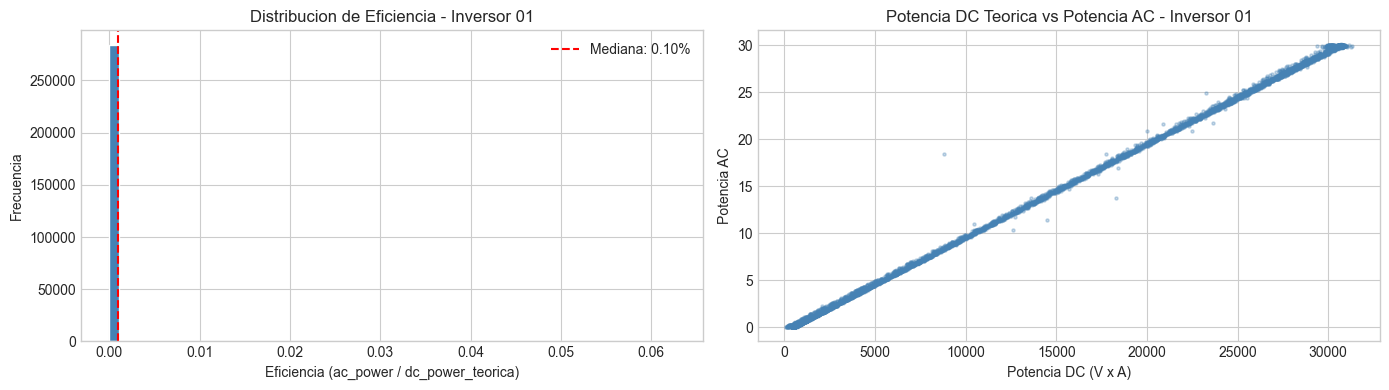


Registros con inconsistencia fisica (eficiencia > 105% o negativa): 16430 (5.47%)


In [39]:
# Grafico: Distribucion de la eficiencia calculada
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma de eficiencia
axes[0].hist(df_valido['eficiencia'], bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(df_valido['eficiencia'].median(), color='red', linestyle='--', label=f"Mediana: {df_valido['eficiencia'].median():.2%}")
axes[0].set_title('Distribucion de Eficiencia - Inversor 01')
axes[0].set_xlabel('Eficiencia (ac_power / dc_power_teorica)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Scatter: Potencia DC vs AC para ver la relacion lineal
muestra_scatter = df_valido.sample(min(5000, len(df_valido)), random_state=42)
axes[1].scatter(muestra_scatter['dc_power_teorica'], muestra_scatter[ac_pow_col],
                alpha=0.3, s=5, color='steelblue')
axes[1].set_title('Potencia DC Teorica vs Potencia AC - Inversor 01')
axes[1].set_xlabel('Potencia DC (V x A)')
axes[1].set_ylabel('Potencia AC')

plt.tight_layout()
plt.savefig(FIGDIR / 'fig19_anexo_distribucion_eficiencia.png', dpi=150, bbox_inches='tight')
plt.show()

# Calculo de inconsistencias fisicas
n_inconsistencias = len(df_dia) - len(df_valido)
print(f"\nRegistros con inconsistencia fisica (eficiencia > 105% o negativa): {n_inconsistencias} ({n_inconsistencias/len(df_dia)*100:.2f}%)")

In [40]:
# NOTA: ac_power esta en kW, dc_voltage * dc_current esta en Watts
# Para comparar correctamente convertimos ac_power a Watts (* 1000)

df_dia['dc_power_w']     = df_dia[dc_volt_col] * df_dia[dc_curr_col]  # Watts
df_dia['ac_power_w']     = df_dia[ac_pow_col] * 1000                  # kW -> W
df_dia['eficiencia_real'] = df_dia['ac_power_w'] / df_dia['dc_power_w']

# Filtrar eficiencias fisicamente posibles
df_ef = df_dia[(df_dia['eficiencia_real'] > 0) & (df_dia['eficiencia_real'] <= 1.05)]

print("=== Eficiencia Real tras conversion de unidades ===")
print(df_ef['eficiencia_real'].describe().round(4))
print(f"\nEficiencia mediana: {df_ef['eficiencia_real'].median():.2%}")
print(f"Eficiencia promedio: {df_ef['eficiencia_real'].mean():.2%}")
print(f"Eficiencia minima:  {df_ef['eficiencia_real'].min():.2%}")
print(f"Eficiencia maxima:  {df_ef['eficiencia_real'].max():.2%}")

=== Eficiencia Real tras conversion de unidades ===
count    283879.0000
mean          0.8816
std           0.1969
min           0.0018
25%           0.9047
50%           0.9678
75%           0.9771
max           1.0498
Name: eficiencia_real, dtype: float64

Eficiencia mediana: 96.78%
Eficiencia promedio: 88.16%
Eficiencia minima:  0.18%
Eficiencia maxima:  104.98%


## 7. Perfil Diario Promedio (Patron de Generacion por Hora)

Agrupamos por hora del dia para obtener el perfil de generacion tipico.
En un sistema solar fotovoltaico, esperamos una curva de campana:
- Madrugada/noche: valores en 0
- Manana: subida gradual desde el amanecer
- Mediodia: pico maximo
- Tarde/noche: descenso hasta 0

El horario exacto del pico y del amanecer/atardecer nos puede indicar la zona geografica.

In [41]:
# Columnas de potencia AC de todos los inversores
cols_ac_power = [c for c in df.columns if 'ac_power' in c]

# Potencia total combinada de todos los inversores
df['total_ac_power'] = df[cols_ac_power].sum(axis=1)

# Perfil diario: promedio de potencia por hora del dia
perfil_hora = df.groupby(df.index.hour)['total_ac_power'].mean()

print("Potencia AC total promedio por hora del dia:")
print(perfil_hora.round(2).to_string())

# Primera y ultima hora con generacion real (> 1% del maximo)
max_pot = perfil_hora.max()
horas_activas = perfil_hora[perfil_hora > max_pot * 0.01]
print(f"\nHora de inicio de generacion: {horas_activas.index.min()}:00 hrs")
print(f"Hora de fin de generacion:    {horas_activas.index.max()}:00 hrs")
print(f"Hora de pico maximo:          {perfil_hora.idxmax()}:00 hrs")
print(f"Potencia pico promedio:       {max_pot:.2f} unidades")

Potencia AC total promedio por hora del dia:
measured_on
0       0.000000
1       0.000000
2       0.000000
3       0.000000
4       0.000000
5       0.010000
6       3.380000
7      44.450001
8     176.410004
9     327.350006
10    438.559998
11    497.440002
12    513.049988
13    500.440002
14    449.549988
15    357.959991
16    247.750000
17    137.899994
18     49.450001
19      7.240000
20      0.370000
21      0.000000
22      0.000000
23      0.000000

Hora de inicio de generacion: 7:00 hrs
Hora de fin de generacion:    19:00 hrs
Hora de pico maximo:          12:00 hrs
Potencia pico promedio:       513.05 unidades


C:\Users\MAXIMILIANO\AppData\Local\Temp\ipykernel_13280\2254391447.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['total_ac_power'] = df[cols_ac_power].sum(axis=1)


## 8. Comprension del Sistema desde los Datos

Derivamos el contexto del sistema unicamente desde los datos, sin depender de documentacion externa.
Analizamos: capacidad maxima, voltaje AC, latitud estimada y patron laboral vs fin de semana.

In [42]:
# 8.1 Capacidad maxima del sistema
cols_ac_power = [c for c in df.columns if 'ac_power' in c and c != 'total_ac_power']

print("=== Capacidad Maxima Observada ===")
print(f"Potencia AC total maxima absoluta: {df['total_ac_power'].max():.2f} kW")
print(f"Potencia AC total media (todas las horas): {df['total_ac_power'].mean():.2f} kW")
print(f"Potencia AC total media (solo horas diurnas): {df[df['total_ac_power'] > 1]['total_ac_power'].mean():.2f} kW")

print("\n--- Maximo por inversor ---")
max_por_inversor = df[cols_ac_power].max().sort_values(ascending=False)
print(max_por_inversor.round(2).to_string())

=== Capacidad Maxima Observada ===
Potencia AC total maxima absoluta: 721.61 kW
Potencia AC total media (todas las horas): 156.32 kW


Potencia AC total media (solo horas diurnas): 330.80 kW

--- Maximo por inversor ---
inv_07_ac_power_inv_149613     105.339996
inv_04_ac_power_inv_149598     103.709999
inv_23_ac_power_inv_149693      30.110001
inv_01_ac_power_inv_149583      30.100000
inv_19_ac_power_inv_149673      30.100000
inv_20_ac_power_inv_149678      30.100000
inv_22_ac_power_inv_149688      30.090000
inv_03_ac_power_inv_149593      30.090000
inv_14_ac_power_inv_149648      30.090000
inv_09_ac_power_inv_149623      30.090000
inv_12_ac_power_inv_149638      30.090000
inv_08_ac_power_inv_149618      30.090000
inv_24_ac_power_inv_149698      30.090000
inv_11_ac_power_inv_149633      30.090000
inv_02_ac_power_inv_149588      30.090000
inv_17_ac_power_inv_149663      30.090000
inv_13_ac_power_inv_149643      30.090000
inv_10_ac_power_inv_149628      30.090000
inv_16_ac_power_inv_149658      30.090000
inv_06_ac_power_inv_149608      30.090000
inv_18_ac_power_inv_149668      30.090000
inv_15_ac_power_iinv_149653     3

In [43]:
# 8.2 Voltaje AC - Nivel de conexion a la red
cols_ac_voltage = [c for c in df.columns if 'ac_voltage' in c]

# Solo horas de generacion para no incluir ceros nocturnos
df_dia_voltaje = df[df['total_ac_power'] > 1][cols_ac_voltage]

print("=== Voltaje AC durante horas de generacion ===")
volt_stats = df_dia_voltaje.describe().T[['mean', 'std', 'min', '50%', 'max']]
print(volt_stats.round(2).to_string())

print(f"\nVoltaje AC promedio (todos los inversores): {df_dia_voltaje.mean().mean():.1f} V")
print(f"Voltaje AC maximo observado:               {df_dia_voltaje.max().max():.1f} V")
print(f"Voltaje AC minimo observado:               {df_dia_voltaje[df_dia_voltaje > 0].min().min():.1f} V")

print("\nInterpretacion:")
volt_medio = df_dia_voltaje.mean().mean()
if volt_medio < 150:
    print("  -> Voltaje ~120V: sistema residencial (EE.UU./Canada)")
elif volt_medio < 260:
    print("  -> Voltaje ~220-240V: sistema residencial/comercial (Europa/America Latina)")
elif volt_medio < 420:
    print("  -> Voltaje ~380-400V: sistema trifasico industrial/comercial")
else:
    print(f"  -> Voltaje {volt_medio:.0f}V: nivel de media tension o unidad diferente")

=== Voltaje AC durante horas de generacion ===


                                mean    std  min     50%     max
inv_01_ac_voltage_inv_149582  266.11  74.75  0.0  286.58  304.53
inv_02_ac_voltage_inv_149587  263.69  79.75  0.0  287.38  306.46
inv_03_ac_voltage_inv_149592  284.05  42.20  0.0  290.22  307.85
inv_04_ac_voltage_inv_149597  259.24  87.88  0.0  288.30  347.13
inv_05_ac_voltage_inv_149602  271.56  63.32  0.0  286.02  304.37
inv_06_ac_voltage_inv_149607  254.78  93.57  0.0  288.37  305.89
inv_07_ac_voltage_inv_149612  248.64  99.65  0.0  287.52  311.50
inv_08_ac_voltage_inv_149617  278.22  48.76  0.0  286.62  304.66
inv_09_ac_voltage_inv_149622  286.30  30.70  0.0  289.38  307.04
inv_10_ac_voltage_inv_149627  278.38  45.43  0.0  285.74  304.59
inv_11_ac_voltage_inv_149632  284.12  27.13  0.0  286.76  304.72
inv_12_ac_voltage_inv_149637  286.05  28.78  0.0  288.94  305.39
inv_13_ac_voltage_inv_149642  283.24  38.18  0.0  288.42  304.46
inv_14_ac_voltage_inv_149647  279.39  48.72  0.0  287.81  309.45
inv_15_ac_voltage_inv_149

In [44]:
# 8.3 Estimacion de latitud desde el patron estacional de horas de luz
# En cada mes buscamos la primera y ultima hora con generacion significativa
print("=== Horas de Generacion por Mes (patron estacional) ===")
print(f"{'Mes':>4} | {'Amanecer':>10} | {'Atardecer':>10} | {'Horas de luz':>13} | {'Pico (kW)':>10}")
print("-" * 58)

for mes in sorted(df.index.month.unique()):
    df_mes = df[df.index.month == mes]
    perfil = df_mes.groupby(df_mes.index.hour)['total_ac_power'].mean()
    max_mes = perfil.max()
    umbral = max_mes * 0.02
    horas_con_luz = perfil[perfil > umbral]
    if len(horas_con_luz) > 0:
        amanecer  = horas_con_luz.index.min()
        atardecer = horas_con_luz.index.max()
        horas_luz = atardecer - amanecer + 1
        nombre_mes = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'][mes-1]
        print(f"{nombre_mes:>4} | {amanecer:>8}:00 | {atardecer:>8}:00 | {horas_luz:>11} hrs | {max_mes:>10.1f}")

=== Horas de Generacion por Mes (patron estacional) ===
 Mes |   Amanecer |  Atardecer |  Horas de luz |  Pico (kW)
----------------------------------------------------------
 Ene |        8:00 |       16:00 |           9 hrs |      403.7
 Feb |        7:00 |       17:00 |          11 hrs |      485.2


 Mar |        7:00 |       18:00 |          12 hrs |      483.9
 Abr |        7:00 |       18:00 |          12 hrs |      571.4
 May |        7:00 |       19:00 |          13 hrs |      608.1
 Jun |        6:00 |       19:00 |          14 hrs |      558.6


 Jul |        7:00 |       19:00 |          13 hrs |      533.6
 Ago |        7:00 |       19:00 |          13 hrs |      549.6
 Sep |        7:00 |       18:00 |          12 hrs |      572.6
 Oct |        7:00 |       17:00 |          11 hrs |      563.9


 Nov |        7:00 |       16:00 |          10 hrs |      455.5
 Dic |        7:00 |       16:00 |          10 hrs |      399.1


In [45]:
# 8.4 Patron laboral vs fin de semana
# Si el sistema inyecta todo a la red (planta independiente), no deberia haber diferencia
# Si hay autoconsumoo o afecta la demanda, puede haber diferencia lunes-viernes vs sabado-domingo

df['dia_semana'] = df.index.dayofweek  # 0=lunes, 6=domingo
df['es_fin_de_semana'] = df['dia_semana'] >= 5

# Comparar potencia media durante horas diurnas
df_diurno = df[df['total_ac_power'] > 1]

pot_laboral = df_diurno[~df_diurno['es_fin_de_semana']]['total_ac_power'].mean()
pot_fds     = df_diurno[df_diurno['es_fin_de_semana']]['total_ac_power'].mean()
diff_pct    = (pot_fds - pot_laboral) / pot_laboral * 100

print("=== Patron Laboral vs Fin de Semana (horas diurnas) ===")
print(f"Potencia media dias laborales: {pot_laboral:.2f} kW")
print(f"Potencia media fin de semana:  {pot_fds:.2f} kW")
print(f"Diferencia:                    {diff_pct:+.2f}%")
print()
if abs(diff_pct) < 2:
    print("Interpretacion: Sin diferencia significativa.")
    print("El sistema no esta afectado por la demanda humana (inyecta todo a la red o es autonomo).")
else:
    print(f"Interpretacion: Diferencia de {abs(diff_pct):.1f}% sugiere autoconsumoo o demanda variable.")

C:\Users\MAXIMILIANO\AppData\Local\Temp\ipykernel_13280\619066226.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['dia_semana'] = df.index.dayofweek  # 0=lunes, 6=domingo
C:\Users\MAXIMILIANO\AppData\Local\Temp\ipykernel_13280\619066226.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['es_fin_de_semana'] = df['dia_semana'] >= 5


=== Patron Laboral vs Fin de Semana (horas diurnas) ===
Potencia media dias laborales: 329.84 kW
Potencia media fin de semana:  333.18 kW
Diferencia:                    +1.01%

Interpretacion: Sin diferencia significativa.
El sistema no esta afectado por la demanda humana (inyecta todo a la red o es autonomo).


## 9. Analisis Comparativo de Inversores (Grupos de Capacidad)

Descubrimos que los inversores 04 y 07 tienen una capacidad de generacion de ~105 kW, mientras que los otros 22 inversores llegan a un maximo de ~30 kW.
Vamos a comparar sus perfiles y parametros fisicos para entender por que son diferentes.

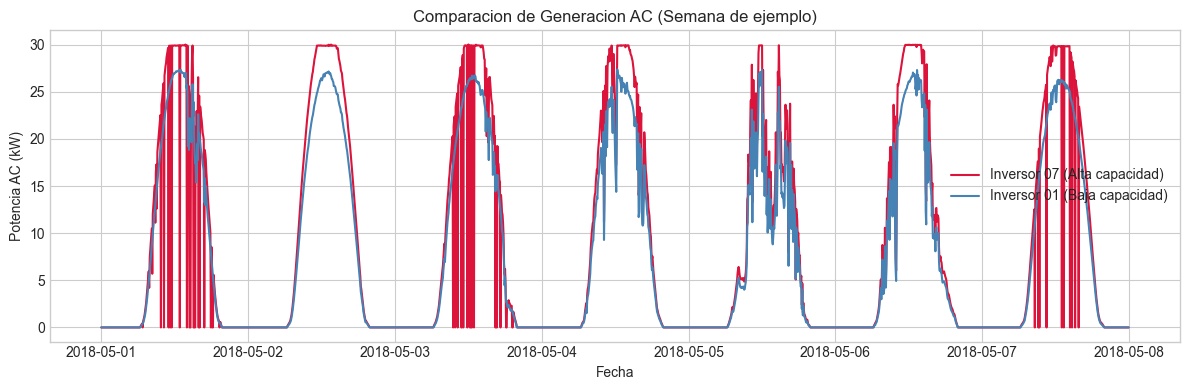

In [46]:
# 9.1 Comparacion de Perfiles de Generacion
# Seleccionamos el inversor 07 (grupo grande) y el inversor 01 (grupo pequeno)
col_ac_07 = [c for c in df.columns if 'inv_07_ac_power' in c][0]
col_ac_01 = [c for c in df.columns if 'inv_01_ac_power' in c][0]

# Extraemos una semana clara de verano (mayor sol)
df_semana = df.loc['2018-05-01':'2018-05-07']

plt.figure(figsize=(12, 4))
plt.plot(df_semana.index, df_semana[col_ac_07], label='Inversor 07 (Alta capacidad)', color='crimson')
plt.plot(df_semana.index, df_semana[col_ac_01], label='Inversor 01 (Baja capacidad)', color='steelblue')
plt.title('Comparacion de Generacion AC (Semana de ejemplo)')
plt.xlabel('Fecha')
plt.ylabel('Potencia AC (kW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(FIGDIR / 'fig20_anexo_comparacion_inversores.png', dpi=150, bbox_inches='tight')
plt.show()

In [47]:
# 9.2 Explicacion Fisica (Corriente vs Voltaje)
# La potencia DC (y por ende la AC) esta dada por Voltaje x Corriente.
# Vamos a ver si los inversores grandes tienen mayor voltaje o mayor corriente.

col_dc_v_07 = [c for c in df.columns if 'inv_07_dc_voltage' in c][0]
col_dc_i_07 = [c for c in df.columns if 'inv_07_dc_current' in c][0]

col_dc_v_01 = [c for c in df.columns if 'inv_01_dc_voltage' in c][0]
col_dc_i_01 = [c for c in df.columns if 'inv_01_dc_current' in c][0]

print("=== Comparacion de Entradas DC (Promedio horas de luz) ===")
# Filtramos solo cuando hay generacion
mask_07 = df[col_dc_i_07] > 0
mask_01 = df[col_dc_i_01] > 0

v_07 = df[mask_07][col_dc_v_07].mean()
i_07 = df[mask_07][col_dc_i_07].mean()

v_01 = df[mask_01][col_dc_v_01].mean()
i_01 = df[mask_01][col_dc_i_01].mean()

print(f"{'Metrica':<20} | {'Inversor 07 (Grande)':<20} | {'Inversor 01 (Pequeno)':<20} | {'Ratio (07/01)':<15}")
print("-" * 80)
print(f"{'Voltaje DC Medio':<20} | {v_07:<20.1f} | {v_01:<20.1f} | {v_07/v_01:<15.2f}")
print(f"{'Corriente DC Media':<20} | {i_07:<20.1f} | {i_01:<20.1f} | {i_07/i_01:<15.2f}")
print(f"{'Potencia Max AC':<20} | {df[col_ac_07].max():<20.1f} | {df[col_ac_01].max():<20.1f} | {df[col_ac_07].max()/df[col_ac_01].max():<15.2f}")

print("\nConclusion Fisica:")
if (i_07/i_01) > 2 and (v_07/v_01) < 1.5:
    print("-> El Inversor 07 recibe muchisima mas corriente a un voltaje similar.")
    print("-> Esto significa que el inversor 07 tiene muchas mas cadenas (strings) de paneles solares")
    print("   conectadas en paralelo en comparacion al inversor 01.")
else:
    print("-> Hay diferencias sustanciales tanto en voltaje como en corriente.")

=== Comparacion de Entradas DC (Promedio horas de luz) ===


Metrica              | Inversor 07 (Grande) | Inversor 01 (Pequeno) | Ratio (07/01)  
--------------------------------------------------------------------------------
Voltaje DC Medio     | 5100330.0            | 668.4                | 7630.78        
Corriente DC Media   | 20.8                 | 20.8                 | 1.00           
Potencia Max AC      | 105.3                | 30.1                 | 3.50           

Conclusion Fisica:
-> Hay diferencias sustanciales tanto en voltaje como en corriente.


In [48]:
# Revisamos el caso atipico del Inversor 07 y 04
cols_anomalas = [
    [c for c in df.columns if 'inv_07_dc_voltage' in c][0],
    [c for c in df.columns if 'inv_04_dc_voltage' in c][0]
]

print(df[cols_anomalas].describe().T)

                                 count          mean           std  min  25%  \
inv_07_dc_voltage_inv_149610  631224.0  2.186519e+06  1.736950e+09  0.0  0.0   
inv_04_dc_voltage_inv_149595  631224.0  3.040377e+02  3.336836e+02  0.0  0.0   

                              50%         75%           max  
inv_07_dc_voltage_inv_149610  0.0  670.101013  1.380000e+12  
inv_04_dc_voltage_inv_149595  0.0  673.172974  1.487769e+03  


In [49]:
# Revisamos la corriente de los inversores grandes vs pequenos
cols_current = [
    [c for c in df.columns if 'inv_07_dc_current' in c][0],
    [c for c in df.columns if 'inv_04_dc_current' in c][0],
    [c for c in df.columns if 'inv_01_dc_current' in c][0]
]

print("=== Corriente DC Maxima Observada ===")
print(df[cols_current].max())

cols_ac_current = [
    [c for c in df.columns if 'inv_07_ac_current' in c][0],
    [c for c in df.columns if 'inv_04_ac_current' in c][0],
    [c for c in df.columns if 'inv_01_ac_current' in c][0]
]

print("\n=== Corriente AC Maxima Observada ===")
print(df[cols_ac_current].max())

=== Corriente DC Maxima Observada ===
inv_07_dc_current_inv_149609    54.273998
inv_04_dc_current_inv_149594    54.467999
inv_01_dc_current_inv_149579    52.348000
dtype: float32

=== Corriente AC Maxima Observada ===
inv_07_ac_current_inv_149611    3.592900e+01
inv_04_ac_current_inv_149596    9.350000e+10
inv_01_ac_current_inv_149581    3.636300e+01
dtype: float32


In [50]:
# Chequeamos la distribucion de AC Power
cols_ac_power = [
    [c for c in df.columns if 'inv_07_ac_power' in c][0],
    [c for c in df.columns if 'inv_04_ac_power' in c][0],
    [c for c in df.columns if 'inv_01_ac_power' in c][0]
]

print("=== Distribucion de AC Power ===")
print(df[cols_ac_power].describe(percentiles=[0.5, 0.9, 0.99]).T)

=== Distribucion de AC Power ===
                               count      mean       std  min  50%        90%  \
inv_07_ac_power_inv_149613  631224.0  5.879789  9.771875  0.0  0.0  25.073000   
inv_04_ac_power_inv_149598  631224.0  6.130343  9.856842  0.0  0.0  25.086000   
inv_01_ac_power_inv_149583  632586.0  6.363338  9.933949  0.0  0.0  25.169001   

                                  99%         max  
inv_07_ac_power_inv_149613  29.957001  105.341003  
inv_04_ac_power_inv_149598  29.952000  103.709999  
inv_01_ac_power_inv_149583  29.938999   30.096001  


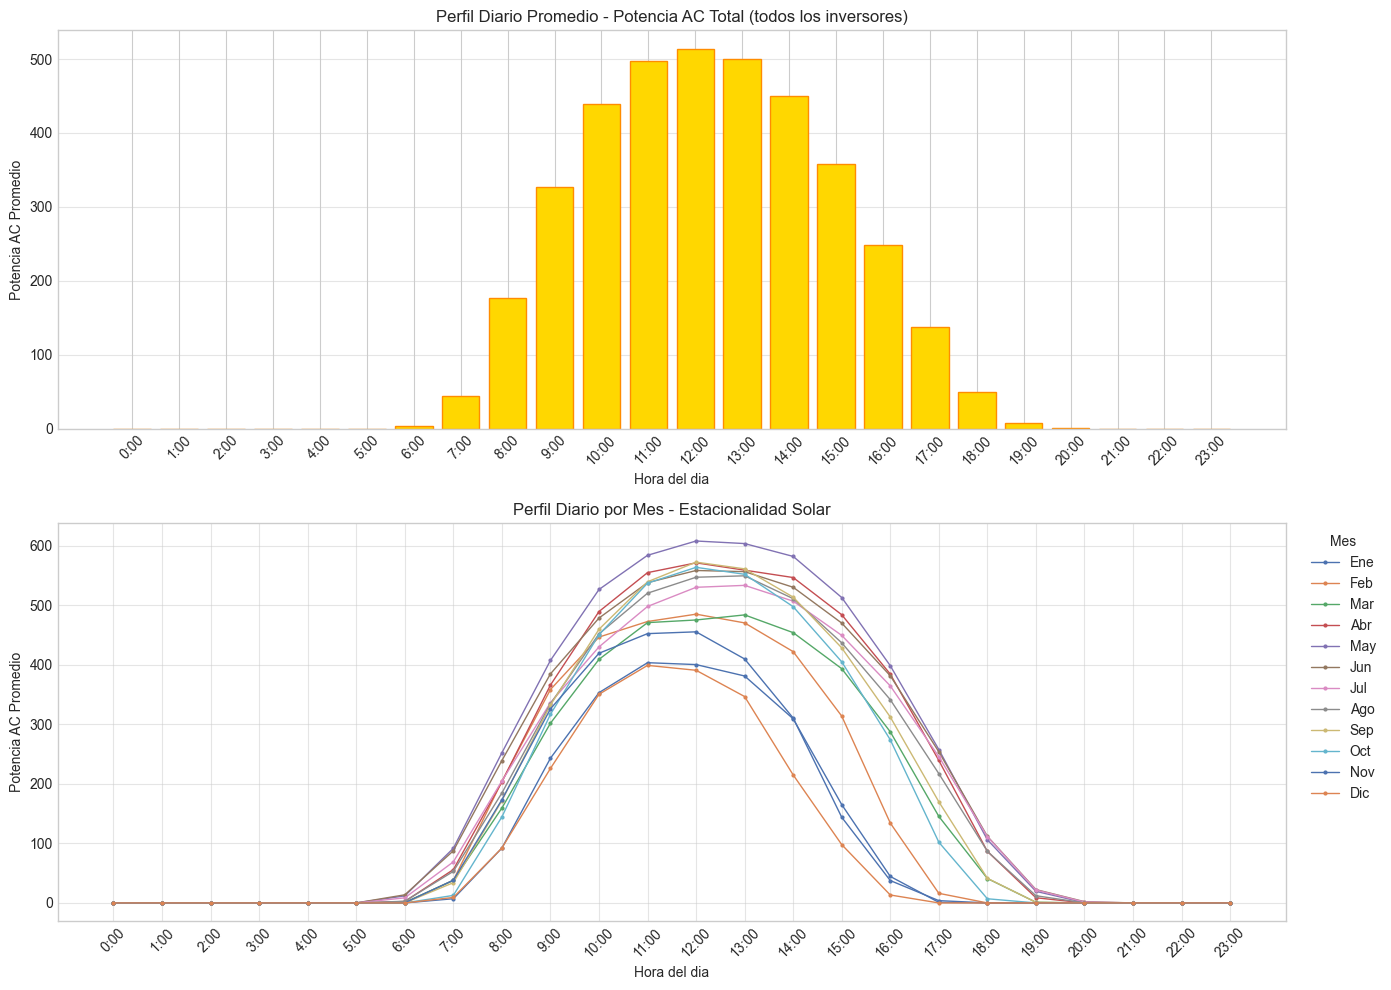

In [51]:
# Perfil diario promedio por mes (para ver estacionalidad)
perfil_mes_hora = df.groupby([df.index.month, df.index.hour])['total_ac_power'].mean().unstack(level=0)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Grafico 1: Perfil horario promedio anual
axes[0].bar(perfil_hora.index, perfil_hora.values, color='gold', edgecolor='darkorange')
axes[0].set_title('Perfil Diario Promedio - Potencia AC Total (todos los inversores)')
axes[0].set_xlabel('Hora del dia')
axes[0].set_ylabel('Potencia AC Promedio')
axes[0].set_xticks(range(24))
axes[0].set_xticklabels([f'{h}:00' for h in range(24)], rotation=45)
axes[0].grid(axis='y', alpha=0.5)

# Grafico 2: Perfil por mes (estacionalidad)
meses = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun',
         7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}
for mes_num in perfil_mes_hora.columns:
    axes[1].plot(perfil_mes_hora.index, perfil_mes_hora[mes_num],
                 marker='o', markersize=2, linewidth=1,
                 label=meses.get(mes_num, str(mes_num)))

axes[1].set_title('Perfil Diario por Mes - Estacionalidad Solar')
axes[1].set_xlabel('Hora del dia')
axes[1].set_ylabel('Potencia AC Promedio')
axes[1].set_xticks(range(24))
axes[1].set_xticklabels([f'{h}:00' for h in range(24)], rotation=45)
axes[1].legend(title='Mes', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].grid(alpha=0.5)

plt.tight_layout()
plt.savefig(FIGDIR / 'fig21_anexo_perfil_mensual.png', dpi=150, bbox_inches='tight')
plt.show()